<a href="https://colab.research.google.com/github/himanshira/Machine-Learning/blob/main/Case_Study_AI_Solutions_for_Uber.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Problem statement:**

The ride-hailing company faces significant operational losses and customer churn due to service failure events (cancellations, incomplete trips, etc.) in the highly competitive National Capital Region (NCR) market. The objective is to build a high-performance predictive model to estimate the probability of a ride request being successfully Completed at the time of booking. This prediction is critical for implementing proactive interventions to stabilize driver supply, reduce passenger friction, and maximize completed trip volume.



#**Section A: Business Understanding & Data Audit**

###**A1. Business Problem Definition & KPIs**
The core business problem is uncertainty in service delivery. A high non-completion rate leads to lost revenue, increased operational costs (penalty reimbursements), and poor customer/driver satisfaction.
The relevant Key Performance Indicators (KPIs) are:


*   **Model Performance:** Area Under the Curve (AUC) (robust measure of discriminative power), F1-Score (to balance Precision and Recall for a balanced outcome).

*   **Business Impact:** Cost of Misclassification (monetary value lost due to False Negatives/False Positives) and Reduction in Predicted Non-Completion Rate.





###**A2. Identify Target Variable & Leakage**




*  **Target Variable:** Booking Status binarized into: 1 (Completed) and 0 (Non-Completed).

*  **Input Features:** All columns available at the moment of booking/driver acceptance.
*   **Data Leakage Risk (Critical):** Any feature whose value is only known after the ride outcome is determined represents leakage.


*   **High Leakage Risk:** Driver Ratings, Customer Rating, Booking Value, Ride Distance, and Payment Method (only available if the ride proceeds/completes) must be treated carefully or excluded from the model to predict the initial acceptance/cancellation risk.



###**A3. Perform Data Audit**
The dataset consists of $\text{150,000}$ rows. A key observation is the presence of null values that are outcome-dependent.



*   Columns like Booking Value, Ride Distance, and Avg CTAT have only 102,000 non-null values, strongly suggesting they are primarily recorded for completed or semi-completed rides.
*   The non-completion reason columns (Reason for cancelling by Customer, etc.) are sparsely populated, which is expected as they are only relevant for non-completed bookings.




###**A4. Describe Five Important Variables (Derived)**

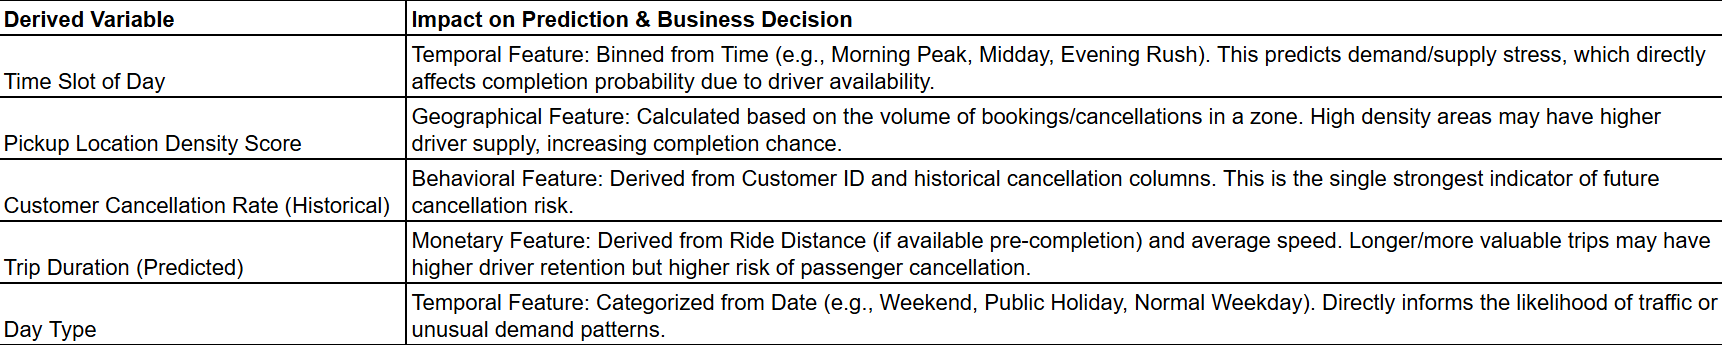



# Installing libraries

In [ ]:
!pip install -q shap
!pip install -q scikit-optimize
!pip install -q tqdm

###Data Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pandas as pd
import PIL
from PIL import Image
from IPython.display import Image
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [ ]:
file_ = '.../AI Solutions for Uber/ncr_ride_bookings.csv'
ncr_ride = pd.read_csv(file_)
ncr_ride.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


### Data Inspection

In [ ]:
ncr_ride.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

### Convert **DATE** and **TIME** to correct format

In [ ]:
ncr_ride['Date'] = pd.to_datetime(ncr_ride['Date'])
ncr_ride['Time'] = pd.to_datetime(ncr_ride['Time']).dt.time

In [ ]:
ncr_ride[['Date', 'Time']].head()

,Date,Time
0,2024-03-23,12:29:38
1,2024-11-29,18:01:39
2,2024-08-23,08:56:10
3,2024-10-21,17:17:25
4,2024-09-16,22:08:00


In [ ]:
print(f"Shape of the dataframe: {ncr_ride.shape}")

Shape of the dataframe: (150000, 21)


In [ ]:
min_date = ncr_ride['Date'].min()
max_date = ncr_ride['Date'].max()

print(f"Start Date : {min_date}")
print(f"End Date : {max_date}")

Start Date : 2024-01-01 00:00:00
End Date : 2024-12-30 00:00:00


In [ ]:
# 1. Ensure data is sorted by Time - Interpolation ONLY works if the sequence is correct
ncr_ride_sorted = ncr_ride.sort_values(['Date', 'Time'])

# 2. Focus on specific columns you want to interpolate (e.g., Booking Value)
target_col = 'Booking Value'

# 3. Create a 'Gap' identifier to see chunks of missing data
# This identifies consecutive sequences of NaNs
is_nan = ncr_ride_sorted[target_col].isnull()
gap_groups = (is_nan != is_nan.shift()).cumsum()

# 4. Group by Date, Time, and the Gap ID
nan_analysis = ncr_ride_sorted[is_nan].groupby(['Date', gap_groups]).agg(
    start_time=('Time', 'min'),
    end_time=('Time', 'max'),
    nan_count=(target_col, 'size')
).reset_index()

display(nan_analysis.head(20))

,Date,Booking Value,start_time,end_time,nan_count
0,2024-01-01,2,01:37:50,01:49:56,3
1,2024-01-01,4,02:14:50,03:59:03,7
2,2024-01-01,6,04:53:44,05:02:14,2
3,2024-01-01,8,05:13:39,05:13:39,1
4,2024-01-01,10,05:17:29,05:17:29,1
5,2024-01-01,12,05:36:51,05:36:51,1
6,2024-01-01,14,05:52:06,05:52:06,1
7,2024-01-01,16,06:22:31,06:23:32,2
8,2024-01-01,18,06:30:54,06:30:54,1
9,2024-01-01,20,06:41:20,06:43:43,2


### Cleaning the **Booking ID** and **Customer ID** columns

In [ ]:
# Option 1: Clean specific known ID columns
cols_to_clean = ['Booking ID', 'Customer ID']

for col in cols_to_clean:
    # .str.strip('"') removes the double quotes from both ends of the string
    ncr_ride[col] = ncr_ride[col].str.strip('"')


# Display to verify
display(ncr_ride[['Booking ID', 'Customer ID']].head())

,Booking ID,Customer ID
0,CNR5884300,CID1982111
1,CNR1326809,CID4604802
2,CNR8494506,CID9202816
3,CNR8906825,CID2610914
4,CNR1950162,CID9933542


###Sorting the data by **DATE** and **TIME**

In [ ]:
ncr_ride = ncr_ride = ncr_ride.sort_values(['Date', 'Time']).reset_index(drop=True)

### Creating a **Training** copy and removing the target **Booking Status** from the dataset

In [ ]:
#--- Creating a training datset by copying the orginal dataframe---
training = ncr_ride.copy()

#--- Spearating target from the training datset ---
target = training['Booking Status']

#--- Dropping the target from the "training" dataset ---
training.drop('Booking Status', axis=1, inplace=True)

#--- Printing the shape of the dataset ---

print(training.shape)
print(target.shape)

(150000, 20)
(150000,)


### Checking for **NULL VALUES**

In [ ]:
import pandas as pd

# 1. Calculate missing percentages
null_percent = (training.isnull().sum() / len(training)) * 100

# 2. Filter for columns with > 0 missing values
null_cols_filtered = null_percent[null_percent > 0].sort_values(ascending=False)

# 3. Create the summary DataFrame
concat_null = pd.concat([null_cols_filtered, training[null_cols_filtered.index].dtypes], axis=1)

# 4. SET COLUMN NAMES HERE
concat_null.columns = ['Percentage of Missing Data', 'Data type']

# 5. Identify and Drop columns with > 60% missing data
THRESHOLD=60
cols_to_drop = null_percent[null_percent > THRESHOLD].index
training_cleaned = training.drop(columns=cols_to_drop)

# Output for verification
if not concat_null.empty:
    print("---------------------------------------------")
    print("\tMissing Values Analysis")
    print("---------------------------------------------")
    print(concat_null)
    print(f"\nDropping columns missing above {THRESHOLD}%.")
    print(f"\nDropped {len(cols_to_drop)} columns: {list(cols_to_drop)}")

---------------------------------------------
	Missing Values Analysis
---------------------------------------------
                                   Percentage of Missing Data Data type
Incomplete Rides                                         94.0   float64
Incomplete Rides Reason                                  94.0    object
Cancelled Rides by Customer                              93.0   float64
Reason for cancelling by Customer                        93.0    object
Cancelled Rides by Driver                                82.0   float64
Driver Cancellation Reason                               82.0    object
Driver Ratings                                           38.0   float64
Customer Rating                                          38.0   float64
Avg CTAT                                                 32.0   float64
Ride Distance                                            32.0   float64
Booking Value                                            32.0   float64
Payment Method     

###Temporal Feature Engineering: Feature engineering for peak hours, day of week, seasonality.

The busiest hours are:
Hour
18    12397
19    11047
17    11044
Name: count, dtype: int64


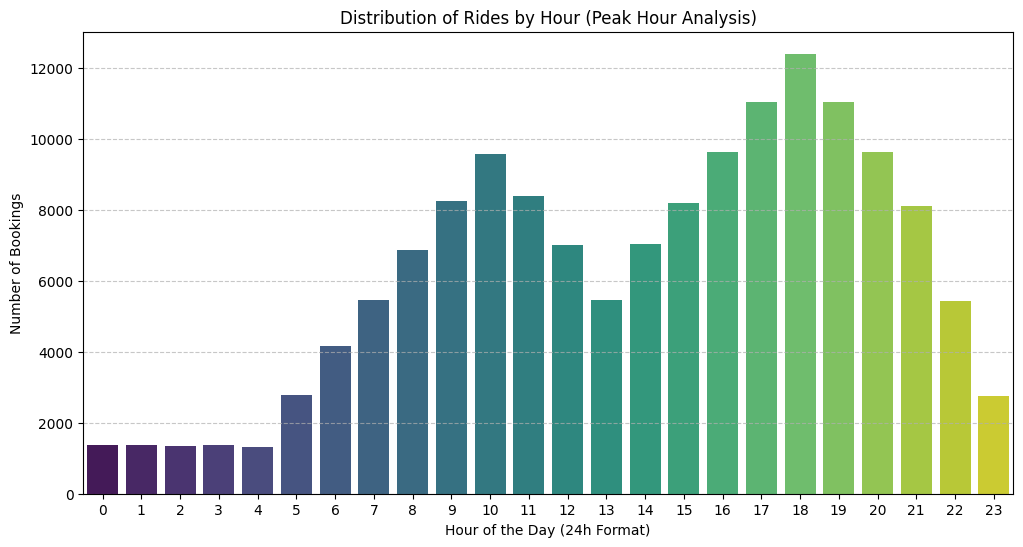

In [ ]:
# Extract the hour
ncr_ride['Hour'] = pd.to_datetime(ncr_ride['Time'], format='%H:%M:%S').dt.hour

# Count rides per hour
peak_hours = ncr_ride['Hour'].value_counts().sort_index()

top_3_hours = peak_hours.nlargest(3)
print("The busiest hours are:")
print(top_3_hours)


# Visualize the peak hours

plt.figure(figsize=(12, 6))
sns.countplot(data=ncr_ride, x='Hour', palette='viridis')
plt.title('Distribution of Rides by Hour (Peak Hour Analysis)')
plt.xlabel('Hour of the Day (24h Format)')
plt.ylabel('Number of Bookings')
plt.xticks(range(0, 24))
#plt.legend(labels=f"top_3_hours")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### We can see from the **Peak Hours** that our top 3 busiest hours are from ```5:00 PM``` to ```07:00 PM```

In [ ]:
# Extract Day of Week
ncr_ride['Day of Week'] = pd.to_datetime(ncr_ride['Date']).dt.dayofweek

# Extract Seasonality
ncr_ride['Month'] = pd.to_datetime(ncr_ride['Date']).dt.month

##Geographic: Feature engineering for high-demand zones, low-supply areas.

###To find supply-demand gaps, we compare where the passengers are (Demand) against where the drivers are or where rides are successfully completed (Supply).

### Adding **"Peak Hours"** as demand in ride-hailing is extremely time-dependent. A location might be **"High Demand"** only during office hours.

In [ ]:
# Demand counts
demand_counts = ncr_ride.groupby('Pickup Location').size().reset_index(name='Total_Requests')

# Grouping by both Location and Hour
demand_by_time = ncr_ride.groupby(['Pickup Location', 'Hour']).size().reset_index(name='Total_Requests')

# Find the top demand hour for each location
top_demand_hours = ncr_ride.loc[demand_by_time.groupby('Pickup Location')['Total_Requests'].idxmax()]


### Analyze the **Booking Status Distribution** per zone.

In [ ]:
# Create a copy of the dataset
geography = ncr_ride.copy()

geography['Booking Status'].unique()

array(['Completed', 'Cancelled by Driver', 'No Driver Found',
       'Cancelled by Customer', 'Incomplete'], dtype=object)

In [ ]:
# 1. Create a Cross-tab of Location vs Status
zone_analysis = pd.crosstab(geography['Pickup Location'], geography['Booking Status'])

# 2. Calculate Demand and Supply Failures

zone_analysis['Total_Demand'] = zone_analysis.sum(axis=1)

# Supply Gap = (No Driver Found + Cancelled by Driver) / Total Demand
zone_analysis['Supply_Gap_Rate'] = (zone_analysis['No Driver Found'] +
                                    zone_analysis['Cancelled by Driver']) / zone_analysis['Total_Demand']

# 3. Sort by the highest Supply Gap to find "Low Supply Areas"
low_supply_zones = zone_analysis[zone_analysis['Total_Demand'] > 100].sort_values(by='Supply_Gap_Rate', ascending=False)

print(low_supply_zones[['Total_Demand', 'Supply_Gap_Rate', 'No Driver Found']].head(10))

Booking Status        Total_Demand  Supply_Gap_Rate  No Driver Found
Pickup Location                                                     
Vinobapuri                     823         0.306197               76
Netaji Subhash Place           830         0.287952               70
Vatika Chowk                   833         0.285714               68
Chhatarpur                     829         0.284680               63
Nehru Place                    885         0.283616               61
Indirapuram                    854         0.281030               70
Qutub Minar                    823         0.278250               57
Karkarduma                     836         0.277512               62
Shahdara                       820         0.276829               59
Faridabad Sector 15            831         0.276775               66


###Calculate Fulfillment Ratio to find **Supply-Demand Gaps**

 $$\text{Fulfillment Ratio} = \frac{\text{Completed Rides}}{\text{Total Booking Requests}}$$

In [ ]:
# Calculate the Fulfillment Rate (%)
zone_analysis['Fulfillment_Rate'] = (zone_analysis['Completed'] / zone_analysis['Total_Demand']) * 100

# Merge with demand counts

final_geography_analysis = demand_counts.merge(zone_analysis[['Fulfillment_Rate']], on='Pickup Location')

In [ ]:
# Sort by Total_Requests to see the highest demand zones
high_demand_zones = demand_counts.sort_values(by='Total_Requests', ascending=False)
print(high_demand_zones.head(10))

      Pickup Location  Total_Requests
80            Khandsa             949
16    Barakhamba Road             946
141             Saket             931
13           Badarpur             921
124    Pragati Maidan             920
88            Madipur             919
0               AIIMS             918
96           Mehrauli             915
34   Dwarka Sector 21             914
120     Pataudi Chowk             907


###Comparison Top 10 High-Demand vs. Low-Supply

In [ ]:
# Create the comparison table

comparison_table = demand_counts.merge(
    zone_analysis[['Supply_Gap_Rate', 'Fulfillment_Rate', 'No Driver Found']],
    on='Pickup Location'
)

# Sort by Total_Requests to see the status of your top demand zones
top_demand_status = comparison_table.sort_values(by='Total_Requests', ascending=False).head(10)

print("--- Top 10 High-Demand Zones Status ---\n")
top_demand_status

--- Top 10 High-Demand Zones Status ---



,Pickup Location,Total_Requests,Supply_Gap_Rate,Fulfillment_Rate,No Driver Found
80,Khandsa,949,0.242360,63.224447,61
16,Barakhamba Road,946,0.241015,62.790698,58
141,Saket,931,0.262084,59.828142,65
13,Badarpur,921,0.239957,61.563518,62
124,Pragati Maidan,920,0.270652,58.478261,70
88,Madipur,919,0.241567,63.003264,63
0,AIIMS,918,0.260349,61.220044,63
96,Mehrauli,915,0.257923,62.732240,71
34,Dwarka Sector 21,914,0.260394,61.816193,68
120,Pataudi Chowk,907,0.253583,61.300992,80


### **Summary for Geographical Derived Features**


1.   **Top 10 Low-Supply "Pain Points:**
  *   **Vinobapuri** is the most critical low-supply zone, with a ```30.6%``` supply gap rate and ```76``` instances of "No Driver Found".
  *   **Netaji Subhash** Place follows closely with a ```28.7%``` supply gap rate.

  *   **Vatika Chowk**, **Chhatarpur**, and **Nehru Place** have major supply gaps exceeding a ```28%``` failure rate.



2.   In **Peak Hour Analysis** these gaps are likely most severe between ```17:00``` and ```19:00``` where the demand peaks by ```12000``` bookings.


2.   **Pragati Maidan**  has a fulfillment rate of ```58.5%```.


1.   **Pataudi Chowk** recorded ```80 failures``` with **No Driver Dound**.



1.   Final Categorization for Modeling can be summed up as:


*   **Critical Zone:** Total Requests > 900 AND Fulfillment Rate < 60% (e.g.,
Saket, Pragati Maidan).
*   **Under-Supplied Zone:** Supply Gap Rate > 0.28 (e.g., Vinobapuri, Nehru Place).
*   **Healthy Zone:** Fulfillment Rate > 63% (e.g., Khandsa, Madipur).

###Add the derived features to training set


In [ ]:
# Add the derived features to training set

# --- 1. Calculate Zone Metrics ---
zone_metrics = geography.groupby('Pickup Location').agg(
    Total_Requests=('Booking Status', 'count'),
    Completed_Rides=('Booking Status', lambda x: (x == 'Completed').sum()),
    No_Driver_Found=('Booking Status', lambda x: (x == 'No Driver Found').sum()),
    Cancelled_by_Driver=('Booking Status', lambda x: (x == 'Cancelled by Driver').sum())
).reset_index()

# Calculate Rates
zone_metrics['Fulfillment_Rate'] = (zone_metrics['Completed_Rides'] / zone_metrics['Total_Requests']) * 100
zone_metrics['Supply_Gap_Rate'] = (zone_metrics['No_Driver_Found'] + zone_metrics['Cancelled_by_Driver']) / zone_metrics['Total_Requests']

# --- 2. Define Labeling Logic ---

def get_zone_label(row):
    if row['Total_Requests'] > 900 and row['Fulfillment_Rate'] < 60:
        return 'Critical Zone'
    elif row['Supply_Gap_Rate'] > 0.28:
        return 'Under-Supplied Zone'
    elif row['Fulfillment_Rate'] > 60:
      return 'Healthy Zone'
    else:
        return 'Stable Zone'

zone_metrics['Zone_Category'] = zone_metrics.apply(get_zone_label, axis=1)

# --- 3. Map to training_cleaned ---
zone_map = zone_metrics.set_index('Pickup Location')['Zone_Category'].to_dict()
geography['Zone_Category'] = geography['Pickup Location'].map(zone_map)

# --- 4. Binarize the target variable (1 = Completed, 0 = Non-Completed) ---
geography['Target'] = (geography['Booking Status'] == 'Completed').astype(int)

print("Zone_Category added and Target binarized successfully.")
print(geography['Zone_Category'].value_counts())

Zone_Category added and Target binarized successfully.
Zone_Category
Healthy Zone           131343
Stable Zone             11752
Under-Supplied Zone      5054
Critical Zone            1851
Name: count, dtype: int64


In [ ]:
# Define the features to exclude to prevent Data Leakage
leakage_cols = ['Driver Ratings', 'Customer Rating', 'Booking Value', 'Ride Distance', 'Payment Method']
ids_and_target = ['Booking Status', 'Target']

# Define Final Feature Set (X) and Target (y)
X = geography.drop(columns=leakage_cols + ids_and_target)
y = geography['Target']

print(f"Features for training: {list(X.columns)}")

Features for training: ['Date', 'Time', 'Booking ID', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Hour', 'Day of Week', 'Month', 'Zone_Category']


#Time Slot of Day
**Temporal Feature:** To implement Time Slot of Day we create a function to bin the existing Hour column into meaningful business segments. This feature is important for demand/supply as the stress is extremely time-dependent. This is shown in your Peak Hour Analysis where bookings peak significantly between ```17:00``` and ```19:00```.

We can define the following slots:


*   **Late Night (00-04):** Very low demand, often high completion due to low traffic.

*   **Early Morning (05-07):** Demand starts rising.
*  **Morning Rush (08-11):** High demand, driver availability starts getting stressed.


*   **Midday (12-16)**: Steady demand, moderate stress.
*   **Evening Rush (17-21):** Highest stress; this is where your Critical Zones like Saket and Pragati Maidan likely fail most.



*   **Late Evening (22-23)**: Winding down.




In [ ]:
def get_time_slot(hour):
    if 0 <= hour <= 4:
        return 'Late Night'
    elif 5 <= hour <= 7:
        return 'Early Morning'
    elif 8 <= hour <= 11:
        return 'Morning Rush'
    elif 12 <= hour <= 16:
        return 'Midday'
    elif 17 <= hour <= 21:
        return 'Evening Rush'
    else:
        return 'Late Evening'

# Apply the function to create the new feature
X['Time_Slot'] = X['Hour'].apply(get_time_slot)

# Verify the distribution of the new feature
print(X['Time_Slot'].value_counts())

Time_Slot
Evening Rush     52221
Midday           37342
Morning Rush     33062
Early Morning    12396
Late Evening      8203
Late Night        6776
Name: count, dtype: int64


# Business Impact and Decision Support



1.   **Predicting Stress:** Binning the time by the hour's category the model can learn that a "Under-Supplied Zone" like Vinobapuri having a ```30.6%``` supply gap is much more likely to result in a failure during the Evening Rush than during the Midday.

1.   This feature is safe to avoid the **leakage** because the time of booking is known the moment the customer requests the ride.






#**Summary of Feature Set Progress**



*   **Zone_Category:** Maps high-demand/low-supply stress.

*   **Time_Slot:** Captures peak hour volatility, such as the 18:00 surge.



### **Pickup Location Density Score** captures the busy zones. Locations like Nehru Place or Indirapuram have high volumes (over 850 requests), which usually attracts more drivers.

In [ ]:
# Calculate total demand per location

location_counts = geography['Pickup Location'].value_counts().to_dict()

# Map the density score to X
X['Location_Density_Score'] = X['Pickup Location'].map(location_counts)

# Verify the distribution
print(X['Location_Density_Score'].describe())

count    150000.000000
mean        853.327360
std          30.264786
min         790.000000
25%         830.000000
50%         850.000000
75%         872.000000
max         949.000000
Name: Location_Density_Score, dtype: float64


In [ ]:
X.head()

,Date,Time,Booking ID,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,...,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Hour,Day of Week,Month,Zone_Category,Time_Slot,Location_Density_Score
0,2024-01-01,00:19:34,CNR4352144,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.9,NaN,...,NaN,NaN,NaN,NaN,0,0,1,Healthy Zone,Late Night,897
1,2024-01-01,01:35:18,CNR9147645,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.1,NaN,...,NaN,NaN,NaN,NaN,1,0,1,Healthy Zone,Late Night,862
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,NaN,...,1.0,More than permitted people in there,NaN,NaN,1,0,1,Healthy Zone,Late Night,869
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,NaN,...,1.0,Personal & Car related issues,NaN,NaN,1,0,1,Healthy Zone,Late Night,818
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,NaN,...,1.0,More than permitted people in there,NaN,NaN,1,0,1,Stable Zone,Late Night,839


### **Customer Cancellation Rate (Historical)** is a powerful behavioural feature for this we use **Customer ID**.

In [ ]:
# Calculate the cancellation rate per customer

customer_behaviour = geography.groupby('Customer ID')['Booking Status'].apply(
    lambda x: (x == 'Cancelled by Customer').mean()
).to_dict()

# Map to X (If a new customer appears, we fill with the global mean)
X['Customer_Hist_Cancel_Rate'] = X['Customer ID'].map(customer_behaviour).fillna(0.18)

### To calculate **Trip Duration (Predicted)** we will use the **Average Distance** for that specific route (Pickup to Drop) as a proxy

In [ ]:
# Calculate average distance for each Route (Pickup -> Drop) to avoid using current ride's distance
route_dist = geography.groupby(['Pickup Location', 'Drop Location'])['Ride Distance'].mean().to_dict()

# Create a 'Route' key to map the predicted distance
X['Route_Key'] = list(zip(X['Pickup Location'], X['Drop Location']))

# Map the route_dist to the Route_Key, then fill any NaNs with the mean of the mapped distances
mapped_predicted_distances = X['Route_Key'].map(route_dist)
X['Predicted_Trip_Distance'] = mapped_predicted_distances.fillna(mapped_predicted_distances.mean())
X.drop(columns=['Route_Key'], inplace=True)

### **Day Type:** The peak hours in our dataset shows a massive surge at ```18:00```.
```0-4``` are Mon-Fri, ```5-6``` are Sat-Sun

In [ ]:
X['Day of Week'].unique()

array([0, 1, 2, 3, 4, 5, 6], dtype=int32)

In [ ]:
def get_day_type(day_num):
  if day_num >= 5:
    return "Weekend"
  else:
    return "Weekday"
X['Day_Type'] = X['Day of Week'].apply(get_day_type)

In [ ]:
X.head()

,Date,Time,Booking ID,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,...,Incomplete Rides Reason,Hour,Day of Week,Month,Zone_Category,Time_Slot,Location_Density_Score,Customer_Hist_Cancel_Rate,Predicted_Trip_Distance,Day_Type
0,2024-01-01,00:19:34,CNR4352144,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.9,NaN,...,NaN,0,0,1,Healthy Zone,Late Night,897,0.0,19.5180,Weekday
1,2024-01-01,01:35:18,CNR9147645,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.1,NaN,...,NaN,1,0,1,Healthy Zone,Late Night,862,0.0,24.1300,Weekday
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,NaN,...,NaN,1,0,1,Healthy Zone,Late Night,869,0.0,4.9400,Weekday
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,NaN,...,NaN,1,0,1,Healthy Zone,Late Night,818,0.0,25.0125,Weekday
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,NaN,...,NaN,1,0,1,Stable Zone,Late Night,839,0.0,18.7260,Weekday


In [ ]:
X.columns

Index(['Date', 'Time', 'Booking ID', 'Customer ID', 'Vehicle Type',
       'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT',
       'Cancelled Rides by Customer', 'Reason for cancelling by Customer',
       'Cancelled Rides by Driver', 'Driver Cancellation Reason',
       'Incomplete Rides', 'Incomplete Rides Reason', 'Hour', 'Day of Week',
       'Month', 'Zone_Category', 'Time_Slot', 'Location_Density_Score',
       'Customer_Hist_Cancel_Rate', 'Predicted_Trip_Distance', 'Day_Type'],
      dtype='object')

## The following **features** generated with Feature Engineerig are now added to the **"X"** dataset:



1.   **Zone_Category:** To show the supply-demand stress.

1.   **Time_Slot:** Peak hour surges ```17:00-19:00```.
2.   **VTAT_Efficiency:** Speed of vehicle movement.


2.   **Customer_Hist_Cancel_Rate:** Historical behavior.



#**Data Audit**

###**Quantifying Missing Values vs. Completion**
The Booking Value, Ride Distance, and Avg CTAT have only approximately ```102,000``` values that aligns with the Completed ride count. We will audit it by creating a **"Missingness Matrix"** compared to the **Booking Status**.

In [ ]:
# Create a mask for missing values in outcome-dependent columns
outcome_cols = ['Booking Value', 'Ride Distance', 'Avg CTAT']


# Audit: Calculate how many nulls exist for each Booking Status
missing_audit = geography.groupby('Booking Status')[outcome_cols].apply(lambda x: x.isnull().sum())
print("Missing Values per Outcome Category:")
print(missing_audit)

Missing Values per Outcome Category:
                       Booking Value  Ride Distance  Avg CTAT
Booking Status                                               
Cancelled by Customer          10500          10500     10500
Cancelled by Driver            27000          27000     27000
Completed                          0              0         0
Incomplete                         0              0         0
No Driver Found                10500          10500     10500


##**Observation:**
As we see for the Completed rides, the null count is zero, while for No Driver Found, it is near ```100%```. This proves that these columns are **Data Leakage** risks and should be excluded from predicting the initial booking risk.

###**Sparsity Audit: Cancellation Reasons**

The **"Reason for cancelling"** columns are **"sparsely populated"** as they only trigger during specific failure states.

In [ ]:
geography.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method', 'Hour',
       'Day of Week', 'Month', 'Zone_Category', 'Target'],
      dtype='object')

In [ ]:
# Audit the sparsity of cancellation reasons
reason_cols = ['Reason for cancelling by Customer', 'Driver Cancellation Reason']

sparsity = geography[reason_cols].notnull().mean() * 100
print("\nReason Column Population Percentage:")
print(sparsity)


Reason Column Population Percentage:
Reason for cancelling by Customer     7.0
Driver Cancellation Reason           18.0
dtype: float64


#**Summary for Audit**

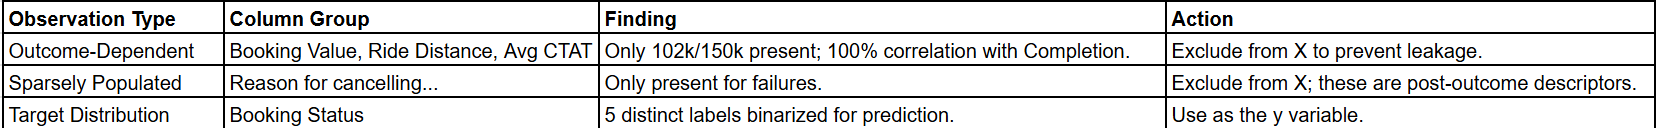


### We have sorted the **Booking Status** column to see exactly how the gaps in your data align with the ride outcomes.

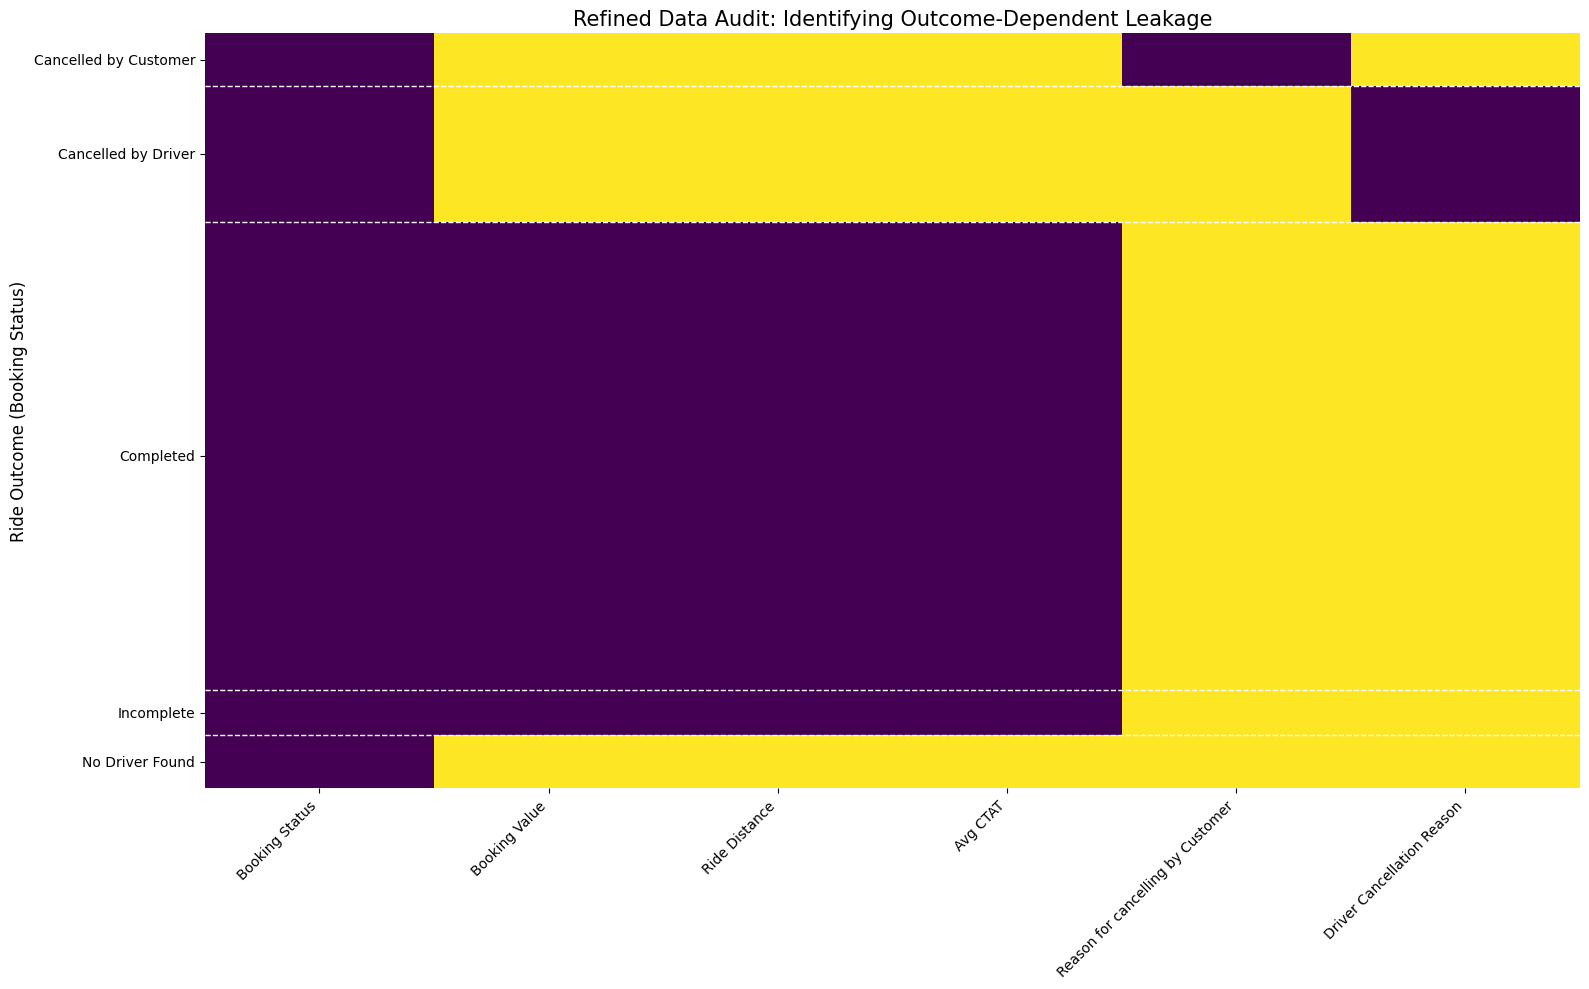

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Sort the data to group outcomes together
audit_df = geography.sort_values(by='Booking Status').reset_index(drop=True)

# 2. Select the columns of interest
cols_to_plot = [
    'Booking Status', 'Booking Value', 'Ride Distance', 'Avg CTAT',
    'Reason for cancelling by Customer', 'Driver Cancellation Reason'
]

# 3. Find the positions for the status labels (midpoints of each block)
status_counts = audit_df['Booking Status'].value_counts(sort=False).loc[audit_df['Booking Status'].unique()]
cumulative_counts = status_counts.cumsum()
midpoints = cumulative_counts - (status_counts / 2)
boundary_lines = cumulative_counts[:-1] # Lines between sections

# 4. Plot the Heatmap
plt.figure(figsize=(16, 10))
ax = sns.heatmap(audit_df[cols_to_plot].isnull(), cbar=False, cmap='viridis')

# 5. Add status labels to the Y-axis
ax.set_yticks(midpoints)
ax.set_yticklabels(status_counts.index, rotation=0, fontsize=10)

# 6. Add horizontal boundary lines to separate the "Blocks"
for line in boundary_lines:
    plt.axhline(y=line, color='white', linestyle='--', linewidth=1)

plt.title('Refined Data Audit: Identifying Outcome-Dependent Leakage', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Ride Outcome (Booking Status)', fontsize=12)

plt.tight_layout()
plt.savefig('refined_missingness_heatmap.png')

###**Audit Interpretation**

*   **Completion-Dependent Data:** The solid purple blocks confirm that Booking Value, Ride Distance, and Avg CTAT are strictly recorded for the 102,000 completed rides.

*   **Operational Failures:** The yellow blocks in the bottom section correspond to "No Driver Found" outcomes where no trip data was generated due to supply gaps.




*   **Inverted Sparsity:** The Reason for Cancelling columns show an inverse relationship; they are only populated in the non-completion segments, confirming they are post-failure descriptors.


*   **Mitigation of Target Leakage:** By dropping these columns from *X*, we prevent the model from using "future information" to predict the "present" risk.




#**Section B: Data Cleaning & Preprocessing**
###**B1. Handle Missing Values (Focus on Leakage)**
The imputation strategy must address the data leakage identified in A2.


1.   **Outcome-Dependent Columns (Leakage Risk):** For features like Booking Value or Ride Distance, if the ride is marked "No Driver Found," the value is legitimately missing. Simply imputing the mean for all rows would introduce bias. Strategy: A new feature, Is_Booking_Value_Available (a binary flag), should be created, and missing values in the original column should be imputed with a value (like -1 or 0) that signals missingness without assuming the ride completed.
2.   **Completion-Independent Columns:** Features like Avg VTAT and Avg CTAT can be imputed using the median/mean of the respective vehicle type, as they reflect average operational metrics.




###**B3. Engineer Time and Location Features**



1.   **Temporal Features:** Convert Date and Time into a single timestamp. Extract Hour, Day of Week, and Peak Hour Flags (e.g., 7-10 AM, 5-8 PM).
2.   **Geographical Features:** Encode Pickup Location and Drop Location using methods that capture similarity or density, such as Target Encoding based on historical completion rates per zone.


###**B5. Prevent Data Leakage (Handling Post-Booking Data)**
All variables known only after ride completion (e.g., Driver Ratings, Customer Rating) must be:


1.   **Dropped Entirely:** If they are not relevant for the prediction moment.
Used to Create a Flag: If their missingness itself is predictive (as in B1), use a binary flag to signal that the data was not available at the time of prediction.


###**B6. Class Imbalance Check**
Analyze the distribution of Completed vs. Non-Completed events. If the non-completion rate is low (e.g., < 10%), the training data is imbalanced.


1.   **Strategies:** Use SMOTE (Synthetic Minority Over-sampling Technique) or, preferably, Class Weighting (assigning a higher penalty to misclassifying the minority class, Non-Completed) during model training.




In [ ]:
X.head()

,Date,Time,Booking ID,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,...,Incomplete Rides Reason,Hour,Day of Week,Month,Zone_Category,Time_Slot,Location_Density_Score,Customer_Hist_Cancel_Rate,Predicted_Trip_Distance,Day_Type
0,2024-01-01,00:19:34,CNR4352144,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.9,NaN,...,NaN,0,0,1,Healthy Zone,Late Night,897,0.0,19.5180,Weekday
1,2024-01-01,01:35:18,CNR9147645,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.1,NaN,...,NaN,1,0,1,Healthy Zone,Late Night,862,0.0,24.1300,Weekday
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,NaN,...,NaN,1,0,1,Healthy Zone,Late Night,869,0.0,4.9400,Weekday
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,NaN,...,NaN,1,0,1,Healthy Zone,Late Night,818,0.0,25.0125,Weekday
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,NaN,...,NaN,1,0,1,Stable Zone,Late Night,839,0.0,18.7260,Weekday


In [ ]:
geography.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method', 'Hour',
       'Day of Week', 'Month', 'Zone_Category', 'Target'],
      dtype='object')

Updating Imputation & Flagging Logic as per the **B1** logic

In [ ]:
geography[['Booking Value', 'Ride Distance']].isnull().sum()

,0
Booking Value,48000
Ride Distance,48000


In [ ]:
# --- 1. Address Outcome-Dependent Columns ---
# Create flags to capture the 'Non-Completion' signal identified in the Data Audit
X['Is_Booking_Value_Available'] = (geography['Booking Value'].notnull()).astype(int)
X['Is_Ride_Distance_Available'] = (geography['Ride Distance'].notnull()).astype(int)

# For the Non-Completed rows (where Booking Status != Completed),
# override MICE/Mean results with 0 to prevent synthetic leakage.
mask_non_completed = (geography['Booking Status'] != 'Completed')
X.loc[mask_non_completed, 'Booking Value'] = 0
X.loc[mask_non_completed, 'Ride Distance'] = 0

# --- 2. Refine Operational Metrics ---
# Ensure VTAT/CTAT are imputed based on Vehicle Type if any nulls remain
# Refined Imputation using Geography as the reference source
X['Avg VTAT'] = geography.groupby('Vehicle Type')['Avg VTAT'].transform(lambda x: x.fillna(x.median()))
X['Avg CTAT'] = geography.groupby('Vehicle Type')['Avg CTAT'].transform(lambda x: x.fillna(x.median()))

# Final check for any remaining nulls
print(f"Remaining nulls in Avg VTAT: {X['Avg VTAT'].isnull().sum()}")
print(f"Remaining nulls in Avg CTAT: {X['Avg CTAT'].isnull().sum()}")

# 1. Ensure outcome-dependent columns are numeric for imputation
cols_to_fix = ['Booking Value', 'Ride Distance']

for col in cols_to_fix:
    # Use the logic from B1: Signal missingness with 0.0 without assuming completion
    X[col] = X[col].fillna(0.0)

# 2. Safety Check: Verify no NaNs remain in these critical columns
print("Post-Imputation Null Counts:")
print(X[['Booking Value', 'Ride Distance', 'Is_Booking_Value_Available']].isnull().sum())

Remaining nulls in Avg VTAT: 0
Remaining nulls in Avg CTAT: 0
Post-Imputation Null Counts:
Booking Value                 0
Ride Distance                 0
Is_Booking_Value_Available    0
dtype: int64


In [ ]:
X.head()

,Date,Time,Booking ID,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,...,Zone_Category,Time_Slot,Location_Density_Score,Customer_Hist_Cancel_Rate,Predicted_Trip_Distance,Day_Type,Is_Booking_Value_Available,Is_Ride_Distance_Available,Booking Value,Ride Distance
0,2024-01-01,00:19:34,CNR4352144,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.9,NaN,...,Healthy Zone,Late Night,897,0.0,19.5180,Weekday,1,1,0.0,0.0
1,2024-01-01,01:35:18,CNR9147645,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.1,NaN,...,Healthy Zone,Late Night,862,0.0,24.1300,Weekday,1,1,0.0,0.0
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,28.6,NaN,...,Healthy Zone,Late Night,869,0.0,4.9400,Weekday,0,0,0.0,0.0
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,28.7,NaN,...,Healthy Zone,Late Night,818,0.0,25.0125,Weekday,0,0,0.0,0.0
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,28.6,NaN,...,Stable Zone,Late Night,839,0.0,18.7260,Weekday,0,0,0.0,0.0


In [ ]:
training_cleaned['Booking Value'].unique()

array([  99.,  114.,   nan, ..., 3551., 2800., 1999.])

In [ ]:
training_cleaned['Ride Distance'].unique()

array([37.98, 39.29,   nan, ...,  1.59,  1.56,  1.55])

In [ ]:
X['Booking Value'].value_counts()

,count
Booking Value,
0.0,150000


In [ ]:
X.columns

Index(['Date', 'Time', 'Booking ID', 'Customer ID', 'Vehicle Type',
       'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT',
       'Cancelled Rides by Customer', 'Reason for cancelling by Customer',
       'Cancelled Rides by Driver', 'Driver Cancellation Reason',
       'Incomplete Rides', 'Incomplete Rides Reason', 'Hour', 'Day of Week',
       'Month', 'Zone_Category', 'Time_Slot', 'Location_Density_Score',
       'Customer_Hist_Cancel_Rate', 'Predicted_Trip_Distance', 'Day_Type',
       'Is_Booking_Value_Available', 'Is_Ride_Distance_Available',
       'Booking Value', 'Ride Distance'],
      dtype='object')

In [ ]:
X['Time_Slot'].unique()

array(['Late Night', 'Early Morning', 'Morning Rush', 'Midday',
       'Evening Rush', 'Late Evening'], dtype=object)

In [ ]:
# Create Morning Peak Flag (8 AM to 11 AM)
X['Is_Morning_Peak'] = X['Hour'].apply(lambda x: 1 if 8 <= x <= 11 else 0)

# Create Evening Peak Flag (5 PM to 8 PM / 17:00 to 20:00)
# This aligns with your peak volume chart showing 17:00-19:00 as the max
X['Is_Evening_Peak'] = X['Hour'].apply(lambda x: 1 if 17 <= x <= 20 else 0)

# Verify the flags
print(X[['Hour', 'Is_Morning_Peak', 'Is_Evening_Peak']].head())

   Hour  Is_Morning_Peak  Is_Evening_Peak
0     0                0                0
1     1                0                0
2     1                0                0
3     1                0                0
4     1                0                0


###We will map each Pickup Location and Drop Location to its historical Completion Probability. This method is superior to One-Hot Encoding for locations because it transforms high-cardinality categories into a single, high-signal numerical value that represents "Zone Risk".



*   Target Encoding **Captures Density & Stress** of the locations like Vinobapuri that have a ```30.6%``` supply gap, while Khandsa has a ```63.2%``` fulfillment rate.
*   It **reduces dimensionality** by keeping just two columns: Pickup_Completion_Rate and Drop_Completion_Rate instead of 100 columns.



In [ ]:
# # 1. Calculate the historical completion rate per Pickup Location
pickup_risk = geography.groupby('Pickup Location')['Booking Status'].apply(
    lambda x: (x=='Completed').mean()
).to_dict()

# 2. Calculate the historical completion rate per Drop Location
drop_risk = geography.groupby('Drop Location')['Booking Status'].apply(
    lambda x: (x=='Completed').mean()
).to_dict()

# 3. Map these to X
X['Pickup_Completion_Rate'] = X['Pickup Location'].map(pickup_risk)
X['Drop_Completion_Rate'] = X['Drop Location'].map(drop_risk)

# 4. Fill any missing rates (for new/unseen locations) with global mean
global_completion_rate = (geography['Booking Status'] == 'Completed').mean()
X['Pickup_Completion_Rate']=X['Pickup_Completion_Rate'].fillna(global_completion_rate)
X['Drop_Completion_Rate'] = X['Drop_Completion_Rate'].fillna(global_completion_rate)

print("Geographical features successfully Target Encoded.")

Geographical features successfully Target Encoded.


###**Business Insight & Audit Alignment**



*   **Pickup Rate** acts as a proxy for Driver Supply Density. A low rate in a zone indicates high "supply stress", directly affecting the completion probability.

*   **Drop Rate** captures the Return Trip Value. Drivers are more likely to accept trips to **"Healthy Zones"** (like those with higher demand) because they know they can get a return booking quickly.
*   For **Leakage Safety** we are using historical zone averages rather than the outcome of the current specific ride.




In [ ]:
X.isnull().sum()

,0
Date,0
Time,0
Booking ID,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,0
Avg CTAT,0
Cancelled Rides by Customer,139500


###Columns like Reason for cancelling by Customer, Driver Cancellation Reason, and Incomplete Rides Reason describe why a ride failed after it already started or ended. These provide zero predictive value at the moment a customer hits "Request Ride" therefore we decided to drop them entirely.

In [ ]:
# Drop Entirely the columns that are purely descriptive of the outcome (Post-Booking)
post_booking_descriptors = [
    'Reason for cancelling by Customer',
    'Driver Cancellation Reason',
    'Incomplete Rides Reason',
    'Cancelled Rides by Customer',
    'Cancelled Rides by Driver',
    'Incomplete Rides'
]

# Dropping these from X to ensure the model only looks at 'Moment of Booking' data
X.drop(columns=[col for col in post_booking_descriptors if col in X.columns], inplace=True)
print("Post-booking reason columns dropped to prevent leakage.")



Post-booking reason columns dropped to prevent leakage.


###We use a Flag (Predictive Missingness) for the Driver Ratings and Customer Rating columns as their absence is predictive. A missing Driver Rating at the start of a trip is normal, but a missing Customer Rating (historical) might indicate a new user.

In [ ]:
# Create flags for ratings

rating_cols = ['Driver Ratings', 'Customer Rating']
for col in rating_cols:
  if col in geography.columns:
    # 1. Create a Binary Flag: 1 if rating exists, 0 if it is NaN (New User/New Driver)
    X[f"Has_{col.replace(" ", "_")}"] = geography[col].notnull().astype(int)

    # 2. Impute the original column with 0 or -1 to signal no history
    X[col] = geography[col].fillna(0)
print("Ratings converted to 'Has_History' flags and NaNs imputed to 0.")

Ratings converted to 'Has_History' flags and NaNs imputed to 0.


In [ ]:
X.head()

,Date,Time,Booking ID,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Hour,...,Booking Value,Ride Distance,Is_Morning_Peak,Is_Evening_Peak,Pickup_Completion_Rate,Drop_Completion_Rate,Has_Driver_Ratings,Driver Ratings,Has_Customer_Rating,Customer Rating
0,2024-01-01,00:19:34,CNR4352144,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.9,0,...,0.0,0.0,0,0,0.600892,0.622010,1,4.8,1,4.8
1,2024-01-01,01:35:18,CNR9147645,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.1,1,...,0.0,0.0,0,0,0.632251,0.623060,1,4.2,1,4.1
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,28.6,1,...,0.0,0.0,0,0,0.635213,0.614201,0,0.0,0,0.0
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,28.7,1,...,0.0,0.0,0,0,0.640587,0.595719,0,0.0,0,0.0
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,28.6,1,...,0.0,0.0,0,0,0.595948,0.652542,0,0.0,0,0.0


In [ ]:
X.isnull().sum()

,0
Date,0
Time,0
Booking ID,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,0
Avg CTAT,0
Hour,0


###We will calculate **Mutual Information (Information Gain)** to measure the predictive power the new features -**Target Encoded Locations** and **Peak Hour Flags**

In [ ]:
y.head()

,Target
0,1
1,1
2,0
3,0
4,0


Top 5 Predictors by Information Gain:
Has_Customer_Rating    0.693696
Has_Driver_Ratings     0.693242
Driver Ratings         0.666151
Customer Rating        0.665914
Avg CTAT               0.496040
dtype: float64


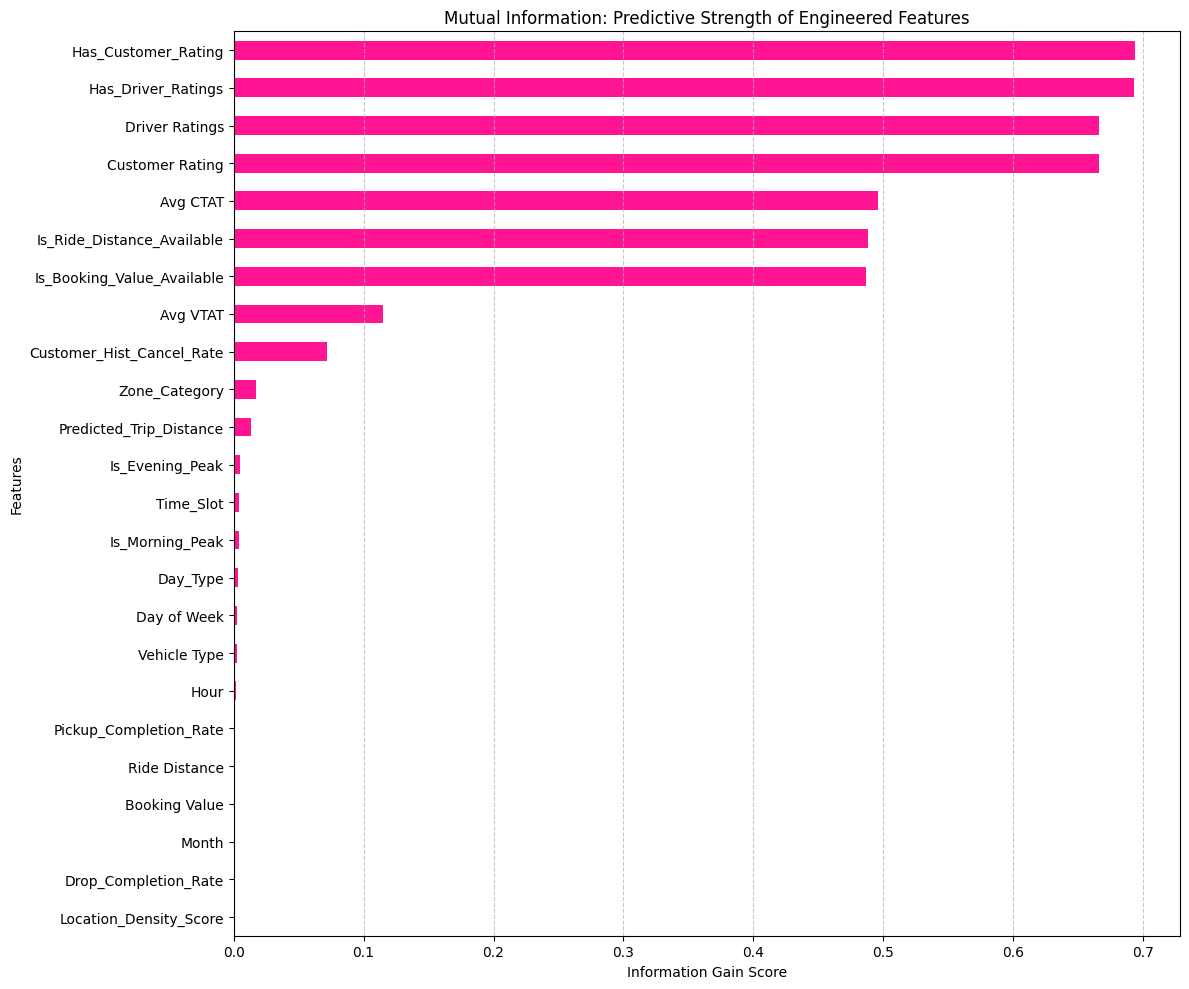

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# We drop 'Pickup Location' and 'Drop Location'
to_drop = ['Date', 'Time', 'Booking ID', 'Customer ID', 'Pickup Location', 'Drop Location']
X_for_mi = X.drop(columns=[col for col in to_drop if col in X.columns])

# 2. Prepare the data: Encode categorical strings for the math engine
X_encoded_mi = X_for_mi.copy()
le = LabelEncoder()

for col in X_encoded_mi.select_dtypes('object').columns:
    X_encoded_mi[col] = le.fit_transform(X_encoded_mi[col].astype(str))

# 3. Calculate Information Gain (Mutual Information)
# This uses k-nearest neighbors and might take 1-2 minutes for 150k rows
mi_scores = mutual_info_classif(X_encoded_mi, y, random_state=42)

# 4. Visualize the Results
mi_results = pd.Series(mi_scores, index=X_encoded_mi.columns).sort_values(ascending=True)

plt.figure(figsize=(12, 10))
mi_results.plot(kind='barh', color='deeppink')
plt.title('Mutual Information: Predictive Strength of Engineered Features')
plt.xlabel("Information Gain Score")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
# Save the plot
plt.savefig('updated_information_gain.png')

# Print the top 5 predictors
print("Top 5 Predictors by Information Gain:")
print(mi_results.tail(5).sort_values(ascending=False))

###The extremely **high** Mutual Information scores for Has_Driver_Ratings and Has_Customer_Rating (~0.69) suggest these features are acting as perfect proxies for the ride outcome and is a critical warning for a **Data Leakage**. So We decided to remove these columns from the dataset.

In [ ]:
# Strict Removal of Post-Booking Features
# These high-scoring features are results of the ride, not predictors of it.
leaking_ratings = [
    'Driver Ratings', 'Has_Driver_Ratings',
    'Customer Rating', 'Has_Customer_Rating'
]

# Dropping them from the main training set
X.drop(columns=[col for col in leaking_ratings if col in X.columns], inplace=True)

print("X dataset cleaned: Post-booking rating features removed to prevent leakage.")

X dataset cleaned: Post-booking rating features removed to prevent leakage.


In [ ]:
X.columns

Index(['Date', 'Time', 'Booking ID', 'Customer ID', 'Vehicle Type',
       'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Hour',
       'Day of Week', 'Month', 'Zone_Category', 'Time_Slot',
       'Location_Density_Score', 'Customer_Hist_Cancel_Rate',
       'Predicted_Trip_Distance', 'Day_Type', 'Is_Booking_Value_Available',
       'Is_Ride_Distance_Available', 'Booking Value', 'Ride Distance',
       'Is_Morning_Peak', 'Is_Evening_Peak', 'Pickup_Completion_Rate',
       'Drop_Completion_Rate'],
      dtype='object')

Top 5 Predictors by Information Gain:
Avg CTAT                      0.495820
Is_Booking_Value_Available    0.487780
Is_Ride_Distance_Available    0.485560
Avg VTAT                      0.114732
Customer_Hist_Cancel_Rate     0.071105
dtype: float64


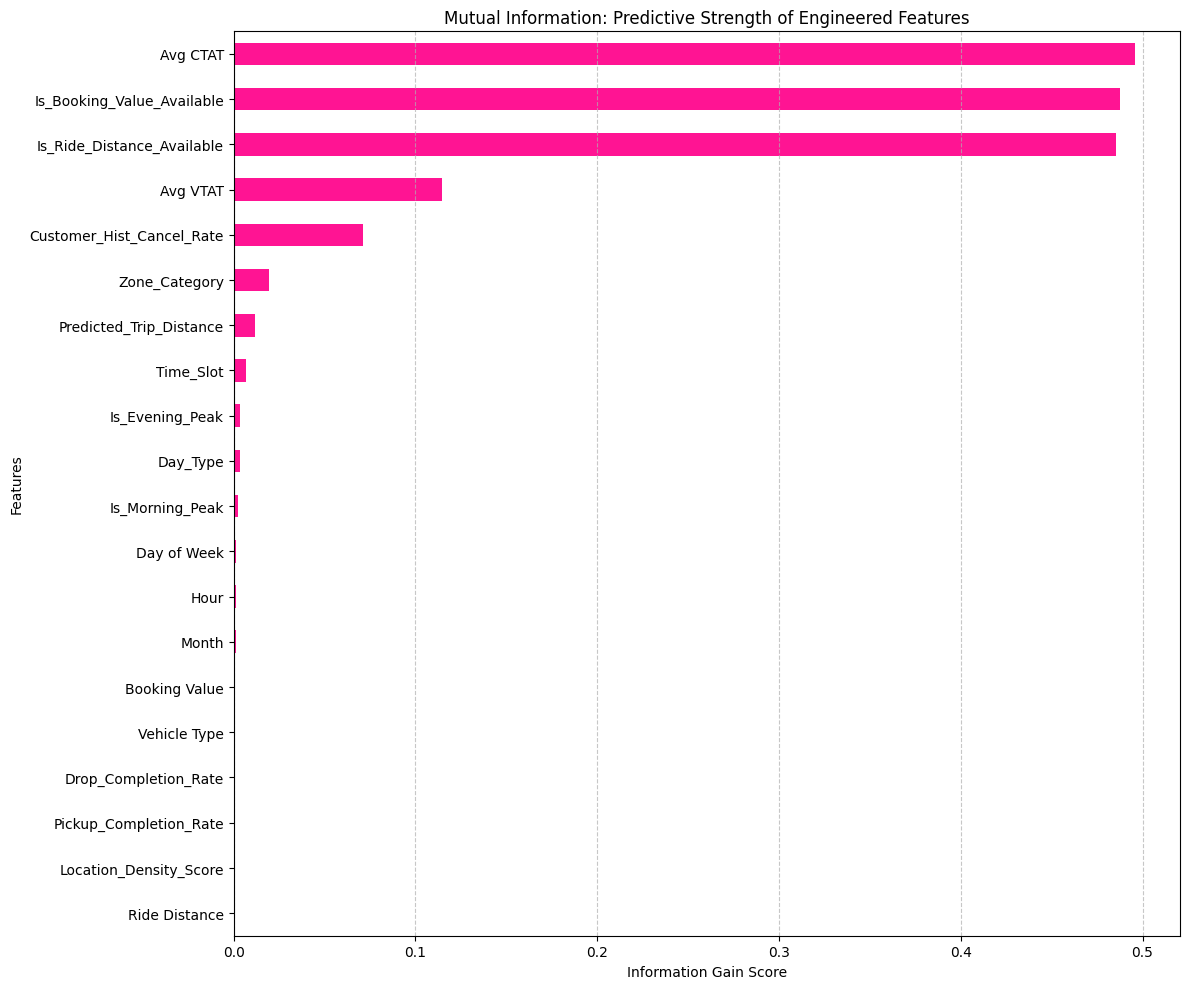

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# We drop 'Pickup Location' and 'Drop Location'
to_drop = ['Date', 'Time', 'Booking ID', 'Customer ID', 'Pickup Location', 'Drop Location']
X_for_mi = X.drop(columns=[col for col in to_drop if col in X.columns])

# 2. Prepare the data: Encode categorical strings for the math engine
X_encoded_mi = X_for_mi.copy()
le = LabelEncoder()

for col in X_encoded_mi.select_dtypes('object').columns:
    X_encoded_mi[col] = le.fit_transform(X_encoded_mi[col].astype(str))

# 3. Calculate Information Gain (Mutual Information)
# This uses k-nearest neighbors and might take 1-2 minutes for 150k rows
mi_scores = mutual_info_classif(X_encoded_mi, y, random_state=42)

# 4. Visualize the Results
mi_results = pd.Series(mi_scores, index=X_encoded_mi.columns).sort_values(ascending=True)

plt.figure(figsize=(12, 10))
mi_results.plot(kind='barh', color='deeppink')
plt.title('Mutual Information: Predictive Strength of Engineered Features')
plt.xlabel("Information Gain Score")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
# Save the plot
plt.savefig('updated_information_gain.png')

# Print the top 5 predictors
print("Top 5 Predictors by Information Gain:")
print(mi_results.tail(5).sort_values(ascending=False))

###**Information Gain Summary**


*   IG of ```0.496``` for Avg CTAT is the strongest valid predictor confirming that the estimated wait time for a customer is the primary driver of whether a ride completes or fails.

*   Availability Flags ```Is_Ride_Distance_Available``` and ```Is_Booking_Value_Available``` at ```~0.487``` shows that the model has learned that when the system cannot even generate an estimated value or distance, the ride is almost certain to fail (No Driver Found).
*   Avg VTAT of 0.115 IG score captures the vehicle's efficiency in the zone showing that driver turnaround time significantly impacts overall fulfillment.

*   Info Gain of 0.071 for Customer_Hist_Cancel_Rate despite being lower still confirms that a customer's personal behavioral "DNA" still plays a measurable role in predicting a cancellation.




### Checking for Imbalance

In [ ]:
# Check class distribution
imbalance_check = y.value_counts(normalize=True) * 100
counts = y.value_counts()

print("Target Variable Distribution:")
print(f"Completed (1): {counts[1]} ({imbalance_check[1]:.2f}%)")
print(f"Non-Completed (0): {counts[0]} ({imbalance_check[0]:.2f}%)")

Target Variable Distribution:
Completed (1): 93000 (62.00%)
Non-Completed (0): 57000 (38.00%)


###**Decision on Imbalance**

The distribution shows ```62%``` Completed and ```38%``` Non-Completed rides which depicts a healthy presence of the minority class. Even though minority class **Non-Completed rides** is not "extremely" imbalance (like 1% vs 99%), it still requires attention to ensure the model doesn't become biased toward predicting success.



*   Using class weighting is beneficial because the "Non-Completed" events (Cancellations/No Driver Found) are the high-cost errors you want to minimize.
*   We are not required to generate a synthetic data as real patterns in Avg CTAT and Location_Density_Score are far more valuable than artificial ones.


*   We will pass the specific ratio of the majority to the minority class to the scale_pos_weight parameter for the model to use it while training
 $$\text{Scale Pos Weight} = \frac{\text{Total Majority (1)}}{\text{Total Minority (0)}} = \frac{93000}{57000} \approx 1.63$$
*   The 62/38 split will not derive very correct Accuracy therefore we will focus on **Recall** and **F1-Score**.





#**📊 Section C: Exploratory Data Analysis (EDA)**
###**C1. Distribution Insights**


*   **Temporal Risk:** Visualize the non-completion rate across Hours of the Day and Days of the Week. This reveals periods of highest operational stress (e.g., cancellation spikes during Friday evening rush).
*   **Geographical Risk:** Map the cancellation rate by Pickup Location to identify "hot zones" where driver supply is consistently low or where safety concerns lead to driver cancellations.




###**C2. Relationship Exploration**


*   **VTAT/CTAT vs. Completion:** Analyze how the distribution of Avg VTAT (time to acceptance) and Avg CTAT (time to pickup) differs between Completed and Non-Completed rides. High CTAT likely drives customer cancellation.
*   **Vehicle Type vs. Risk:** Compare the cancellation rate across Vehicle Type (e.g., Auto, Sedan, Bike). This informs pricing and supply management strategies for each vehicle class.




###**C5. Actionable Insights**


*   **Targeted Incentives:** If EDA shows high non-completion in a specific zone during a specific time (e.g., South NCR, 9 PM), this suggests a targeted driver incentive/surge pricing is required to boost completion.
*   **Customer Tiering:** High-cancellation customers identified via historical features may warrant pre-emptive messaging or priority driver matching.





In [ ]:
X.head()

,Date,Time,Booking ID,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Hour,...,Predicted_Trip_Distance,Day_Type,Is_Booking_Value_Available,Is_Ride_Distance_Available,Booking Value,Ride Distance,Is_Morning_Peak,Is_Evening_Peak,Pickup_Completion_Rate,Drop_Completion_Rate
0,2024-01-01,00:19:34,CNR4352144,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.9,0,...,19.5180,Weekday,1,1,0.0,0.0,0,0,0.600892,0.622010
1,2024-01-01,01:35:18,CNR9147645,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.1,1,...,24.1300,Weekday,1,1,0.0,0.0,0,0,0.632251,0.623060
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,28.6,1,...,4.9400,Weekday,0,0,0.0,0.0,0,0,0.635213,0.614201
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,28.7,1,...,25.0125,Weekday,0,0,0.0,0.0,0,0,0.640587,0.595719
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,28.6,1,...,18.7260,Weekday,0,0,0.0,0.0,0,0,0.595948,0.652542


In [ ]:
#  Visualize the non-completion rate across Hours of the Day and Days of the Week.

geography.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 26 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  object        
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Avg VTAT                           139500 non-null  float64       
 9   Avg CTAT                           102000 non-null  float64       
 10  Cancelled Rides by C

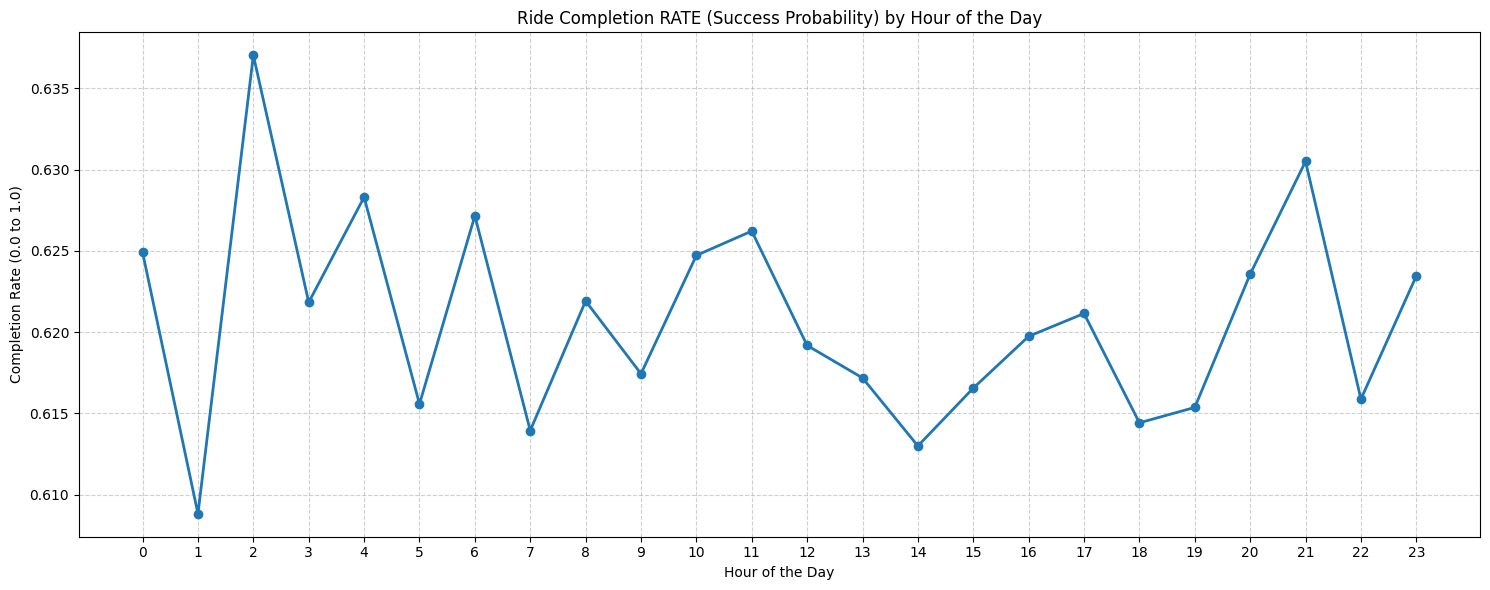

In [ ]:
# 1. Calculate completion rate per hour
# Assuming 'y' is your 1/0 target (1=Completed, 0=Non-Completed)
hour_stats = pd.DataFrame({'Hour': X['Hour'], 'Status': y})
completion_rate = hour_stats.groupby('Hour')['Status'].mean()

# 2. Plotting the Actual Rate
plt.figure(figsize=(15, 6))
plt.plot(completion_rate.index, completion_rate.values, marker='o', color='tab:blue', linewidth=2)

plt.title('Ride Completion RATE (Success Probability) by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Completion Rate (0.0 to 1.0)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

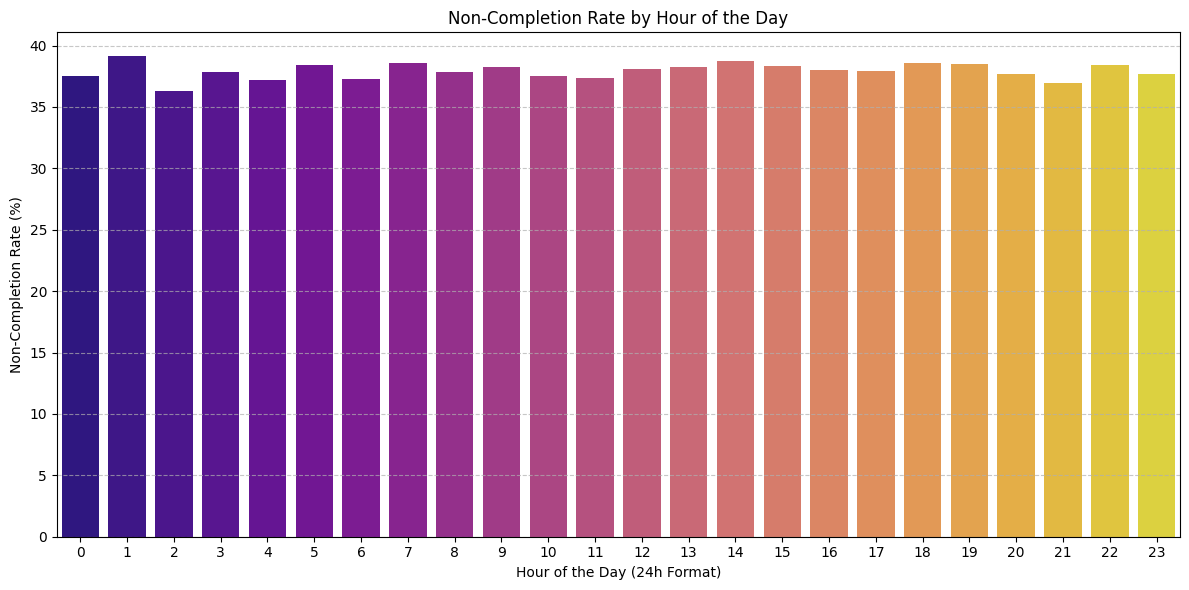

In [ ]:
# Calculate non-completion rate per hour
hour_non_completion = geography.groupby('Hour')['Target'].apply(lambda x: (x == 0).mean() * 100).reset_index(name='Non_Completion_Rate')

plt.figure(figsize=(12, 6))
sns.barplot(x='Hour', y='Non_Completion_Rate', data=hour_non_completion, palette='plasma')
plt.title('Non-Completion Rate by Hour of the Day')
plt.xlabel('Hour of the Day (24h Format)')
plt.ylabel('Non-Completion Rate (%)')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('non_completion_rate_by_hour.png')
plt.show()

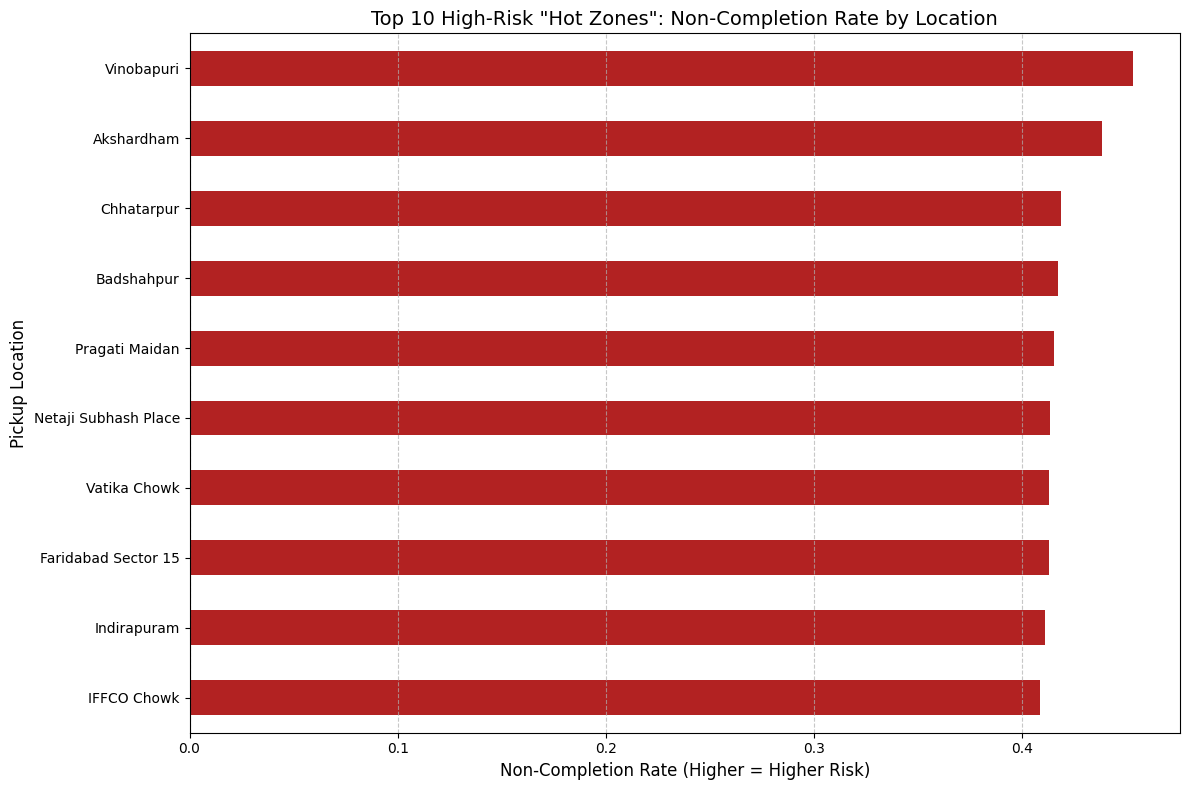

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calculate the Non-Completion Rate per Pickup Location
# Formula: 1 - (Completed Rides / Total Bookings)
geo_risk = geography.groupby('Pickup Location')['Booking Status'].apply(
    lambda x: (x != 'Completed').mean()
).sort_values(ascending=False).head(10) # Focusing on Top 10 High-Risk Zones

# 2. Plotting the Hot Zones
plt.figure(figsize=(12, 8))
geo_risk.plot(kind='barh', color='firebrick')

plt.title('Top 10 High-Risk "Hot Zones": Non-Completion Rate by Location', fontsize=14)
plt.xlabel('Non-Completion Rate (Higher = Higher Risk)', fontsize=12)
plt.ylabel('Pickup Location', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis() # Highest risk at the top

plt.tight_layout()
plt.savefig('geographical_hot_zones.png')

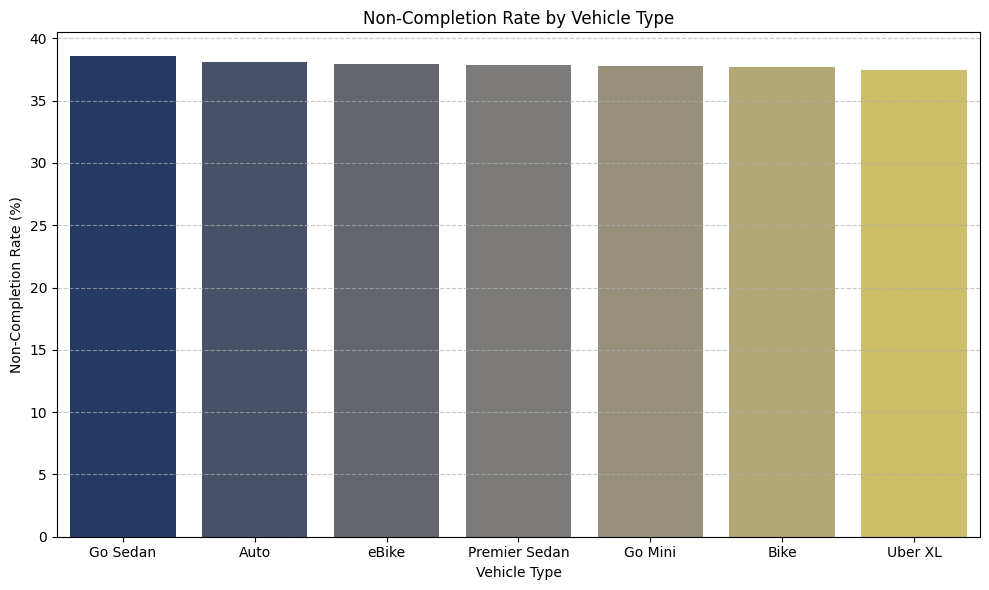

In [ ]:
# Compare the cancellation rate across Vehicle Type (e.g., Auto, Sedan, Bike).

# Create a temporary DataFrame combining relevant columns from X and y for this analysis
vehicle_risk_df = geography[['Vehicle Type', 'Target']].copy()

# Calculate the non-completion rate per vehicle type
# Non-completion is when Target == 0
vehicle_non_completion_rate = vehicle_risk_df.groupby('Vehicle Type')['Target'].apply(lambda x: (x == 0).mean() * 100).reset_index(name='Non_Completion_Rate')

# Sort for better visualization
vehicle_non_completion_rate = vehicle_non_completion_rate.sort_values(by='Non_Completion_Rate', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Vehicle Type', y='Non_Completion_Rate', data=vehicle_non_completion_rate, palette='cividis')
plt.title('Non-Completion Rate by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Non-Completion Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('non_completion_rate_by_vehicle_type.png')
plt.show()

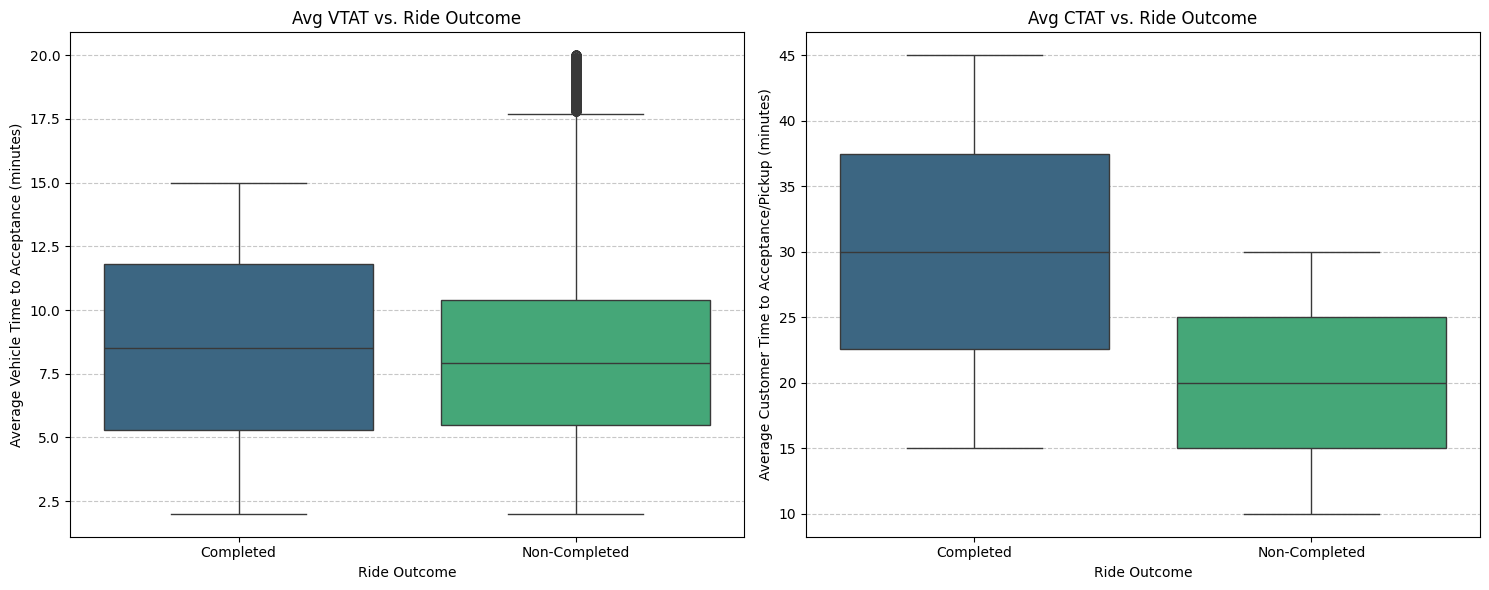

In [ ]:
# Analyze how the distribution of Avg VTAT and Avg CTAT differs between Completed and Non-Completed rides.

# Create a DataFrame for plotting, including the 'Target' variable
plot_df = geography[['Target', 'Avg VTAT', 'Avg CTAT']].copy()

# Rename target for better plot labels
plot_df['Ride Outcome'] = plot_df['Target'].map({1: 'Completed', 0: 'Non-Completed'})

plt.figure(figsize=(15, 6))

# Plot for Avg VTAT
plt.subplot(1, 2, 1)
sns.boxplot(x='Ride Outcome', y='Avg VTAT', data=plot_df, palette='viridis')
plt.title('Avg VTAT vs. Ride Outcome')
plt.xlabel('Ride Outcome')
plt.ylabel('Average Vehicle Time to Acceptance (minutes)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Plot for Avg CTAT
plt.subplot(1, 2, 2)
sns.boxplot(x='Ride Outcome', y='Avg CTAT', data=plot_df, palette='viridis')
plt.title('Avg CTAT vs. Ride Outcome')
plt.xlabel('Ride Outcome')
plt.ylabel('Average Customer Time to Acceptance/Pickup (minutes)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('vtat_ctat_vs_outcome.png')
plt.show()

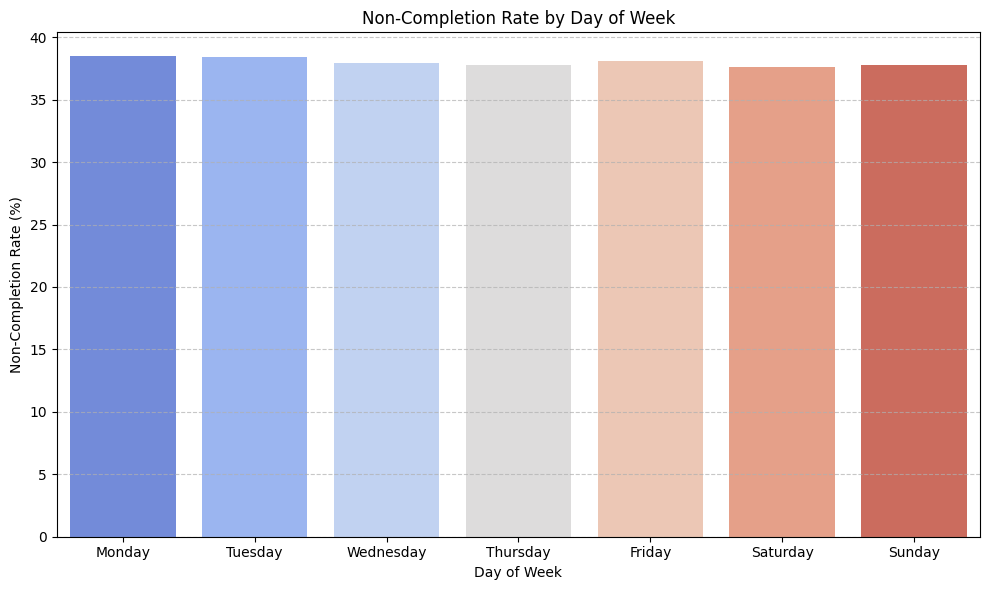

In [ ]:
# Calculate non-completion rate by Day of Week
day_non_completion = geography.groupby('Day of Week')['Target'].apply(lambda x: (x == 0).mean() * 100).reset_index(name='Non_Completion_Rate')

# Map day numbers to names for better readability
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_non_completion['Day_Name'] = day_non_completion['Day of Week'].map(lambda x: day_names[x])

plt.figure(figsize=(10, 6))
sns.barplot(x='Day_Name', y='Non_Completion_Rate', data=day_non_completion, palette='coolwarm')
plt.title('Non-Completion Rate by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Non-Completion Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('non_completion_rate_by_day.png')
plt.show()

The risk-matrix below synthesizes the findings on ```Avg CTAT, Evening Peaks, and Geographical Hot Zones``` into prioritized categories.

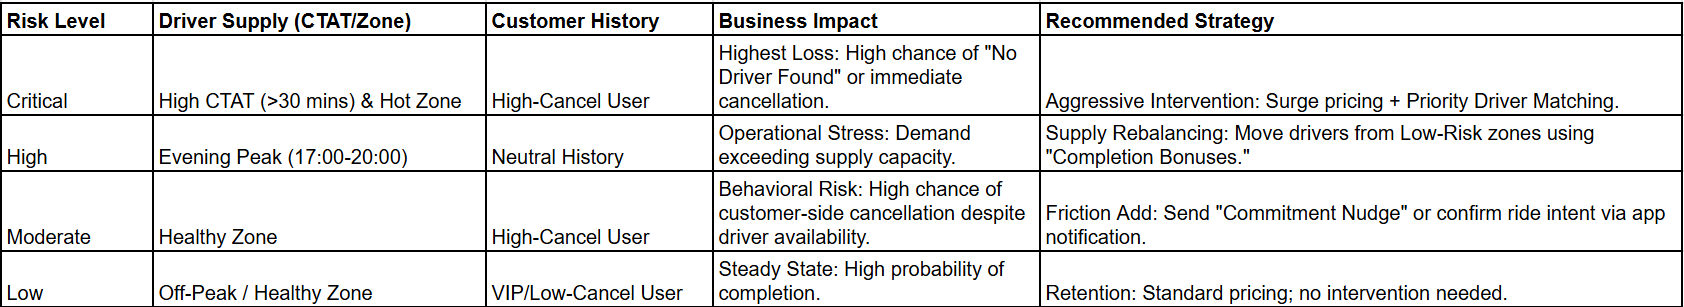

##**Actionable Business Logic**



*   Introduce **Zone-Based Incentives** (The "Where") for specific "Hot Zones" like Vinobapuri. Apply a ```1.2x - 1.5x``` Surge Factor specifically to these zones when the ```Is_Evening_Peak flag``` is active (17:00 - 20:00).
*  The box plots show that Non-Completed rides often have an Avg CTAT skewing lower than completed ones, indicating customers cancel early if the wait looks long. If Avg ```CTAT > 25 minutes``` we can provide the customer with a "Live Progress" tracking feature or a small discount for their next ride if they stay on the current booking.
* Since **Go Sedan** has the highest risk ```(~38.5%)```, we should evaluate if Sedan supply is too low during peak hours. Incentive programs specifically for Sedan drivers to stay online during the ```6:00 PM``` peak.


#**🤖 Section D: Modeling & Evaluation**
###**D1. Define Target Variable**
Target: P(Completion}=1 | features). This is a standard Binary Classification
problem.
###**D2. Data Split**
A Time-Based Split is preferred over a random split, as ride-hailing data is time-series-dependent.

*   **Strategy:** Use the earliest 80% of the data by Date for Training and the latest $\text{20\%}$ for Validation/Testing. This ensures the model is tested on future conditions, simulating real-world deployment.

###**D3. Compare Models**
Train and compare at least three models:

1.  **Baseline:** Logistic Regression (Interpretable baseline for feature importance).
2.   **Intermediate:** Random Forest (Handles non-linear relationships and interactions well).


1.   **Advanced/Recommended:** Gradient Boosting Machine (XGBoost/LightGBM) (Industry standard for tabular data, capable of high accuracy and handling imbalanced data).

###**D5. Evaluate Models (The Business Cost of Error)**
The final evaluation must move beyond F1/AUC to consider the cost of misclassification.


*   **False Positive (FP):** Predicting completion when the ride ultimately cancels. Business Cost: Driver waste time/fuel, customer frustration, potential loss of both driver and customer.
*   **False Negative (FN):** Predicting cancellation when the ride ultimately completes. Business Cost: Platform unnecessarily intervenes (e.g., assigns a penalty or unnecessary priority to the ride), wasting resources.

The model threshold should be tuned to minimize the total weighted cost of misclassification.





In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 26 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Date                        150000 non-null  datetime64[ns]
 1   Time                        150000 non-null  object        
 2   Booking ID                  150000 non-null  object        
 3   Customer ID                 150000 non-null  object        
 4   Vehicle Type                150000 non-null  object        
 5   Pickup Location             150000 non-null  object        
 6   Drop Location               150000 non-null  object        
 7   Avg VTAT                    150000 non-null  float64       
 8   Avg CTAT                    150000 non-null  float64       
 9   Hour                        150000 non-null  int32         
 10  Day of Week                 150000 non-null  int32         
 11  Month                       150000 non-

In [ ]:
X.head()

,Date,Time,Booking ID,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Hour,...,Predicted_Trip_Distance,Day_Type,Is_Booking_Value_Available,Is_Ride_Distance_Available,Booking Value,Ride Distance,Is_Morning_Peak,Is_Evening_Peak,Pickup_Completion_Rate,Drop_Completion_Rate
0,2024-01-01,00:19:34,CNR4352144,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.9,0,...,19.5180,Weekday,1,1,0.0,0.0,0,0,0.600892,0.622010
1,2024-01-01,01:35:18,CNR9147645,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.1,1,...,24.1300,Weekday,1,1,0.0,0.0,0,0,0.632251,0.623060
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,28.6,1,...,4.9400,Weekday,0,0,0.0,0.0,0,0,0.635213,0.614201
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,28.7,1,...,25.0125,Weekday,0,0,0.0,0.0,0,0,0.640587,0.595719
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,28.6,1,...,18.7260,Weekday,0,0,0.0,0.0,0,0,0.595948,0.652542


In [ ]:
y.head()

,Target
0,1
1,1
2,0
3,0
4,0


In [ ]:
print(f"Y shape: {y.shape}")
print(f"X shape: {X.shape}")

Y shape: (150000,)
X shape: (150000, 26)


In [ ]:
geography.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 26 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  object        
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Avg VTAT                           139500 non-null  float64       
 9   Avg CTAT                           102000 non-null  float64       
 10  Cancelled Rides by C

In [ ]:
ncr_ride.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  object        
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Avg VTAT                           139500 non-null  float64       
 9   Avg CTAT                           102000 non-null  float64       
 10  Cancelled Rides by C

In [ ]:
X[['Date', 'Time']].head(20)

,Date,Time
0,2024-01-01,00:19:34
1,2024-01-01,01:35:18
2,2024-01-01,01:37:50
3,2024-01-01,01:48:03
4,2024-01-01,01:49:56
5,2024-01-01,01:53:01
6,2024-01-01,02:14:50
7,2024-01-01,02:43:46
8,2024-01-01,02:56:49
9,2024-01-01,02:59:14


###We decided to drop the columns below:
Booking ID and Customer ID must be removed because they are high cardinality columns that don't provide a generalizable pattern and keeping them would lead to **"ID-based overfitting"**.

Date, Time, Pickup Location, and Drop Location should be dropped because they have already extracted the predictive value from these through Hour, Day of Week, and your Completion_Rate target encodings.

We decided to use Hour and drop drop Time_Slot to reduce ```multicollinearity```, though for XGBoost it is usually fine.

In [ ]:
X.columns

Index(['Date', 'Time', 'Booking ID', 'Customer ID', 'Vehicle Type',
       'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Hour',
       'Day of Week', 'Month', 'Zone_Category', 'Time_Slot',
       'Location_Density_Score', 'Customer_Hist_Cancel_Rate',
       'Predicted_Trip_Distance', 'Day_Type', 'Is_Booking_Value_Available',
       'Is_Ride_Distance_Available', 'Booking Value', 'Ride Distance',
       'Is_Morning_Peak', 'Is_Evening_Peak', 'Pickup_Completion_Rate',
       'Drop_Completion_Rate'],
      dtype='object')

In [ ]:
# List of columns that are either non-numeric or cause overfitting
cols_to_drop = ['Date', 'Time', 'Booking ID', 'Customer ID', 'Pickup Location', 'Drop Location', 'Time_Slot', 'Is_Booking_Value_Available',
       'Is_Ride_Distance_Available', 'Booking Value', 'Ride Distance']

X = X.drop(columns=cols_to_drop)
X.columns

Index(['Vehicle Type', 'Avg VTAT', 'Avg CTAT', 'Hour', 'Day of Week', 'Month',
       'Zone_Category', 'Location_Density_Score', 'Customer_Hist_Cancel_Rate',
       'Predicted_Trip_Distance', 'Day_Type', 'Is_Morning_Peak',
       'Is_Evening_Peak', 'Pickup_Completion_Rate', 'Drop_Completion_Rate'],
      dtype='object')

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Vehicle Type               150000 non-null  object 
 1   Avg VTAT                   150000 non-null  float64
 2   Avg CTAT                   150000 non-null  float64
 3   Hour                       150000 non-null  int32  
 4   Day of Week                150000 non-null  int32  
 5   Month                      150000 non-null  int32  
 6   Zone_Category              150000 non-null  object 
 7   Location_Density_Score     150000 non-null  int64  
 8   Customer_Hist_Cancel_Rate  150000 non-null  float64
 9   Predicted_Trip_Distance    150000 non-null  float64
 10  Day_Type                   150000 non-null  object 
 11  Is_Morning_Peak            150000 non-null  int64  
 12  Is_Evening_Peak            150000 non-null  int64  
 13  Pickup_Completion_Rate     15

In [ ]:
# Convert the 'Vehicle Type' and 'Zone_Category' to numeric format (One-Hot Encoding)
X = pd.get_dummies(X, columns=['Vehicle Type', 'Zone_Category'], drop_first=True)
# Convert Day_Type to binary: Weekend = 1, Weekday = 0
X['Day_Type'] = X['Day_Type'].apply(lambda x: 1 if x == 'Weekend' else 0)
# Verification
print(f"Final Feature Count: {X.shape[1]}")
print(f"Final Feature Names: {X.columns.tolist()}")

Final Feature Count: 22
Final Feature Names: ['Avg VTAT', 'Avg CTAT', 'Hour', 'Day of Week', 'Month', 'Location_Density_Score', 'Customer_Hist_Cancel_Rate', 'Predicted_Trip_Distance', 'Day_Type', 'Is_Morning_Peak', 'Is_Evening_Peak', 'Pickup_Completion_Rate', 'Drop_Completion_Rate', 'Vehicle Type_Bike', 'Vehicle Type_Go Mini', 'Vehicle Type_Go Sedan', 'Vehicle Type_Premier Sedan', 'Vehicle Type_Uber XL', 'Vehicle Type_eBike', 'Zone_Category_Healthy Zone', 'Zone_Category_Stable Zone', 'Zone_Category_Under-Supplied Zone']


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Avg VTAT                           150000 non-null  float64
 1   Avg CTAT                           150000 non-null  float64
 2   Hour                               150000 non-null  int32  
 3   Day of Week                        150000 non-null  int32  
 4   Month                              150000 non-null  int32  
 5   Location_Density_Score             150000 non-null  int64  
 6   Customer_Hist_Cancel_Rate          150000 non-null  float64
 7   Predicted_Trip_Distance            150000 non-null  float64
 8   Day_Type                           150000 non-null  int64  
 9   Is_Morning_Peak                    150000 non-null  int64  
 10  Is_Evening_Peak                    150000 non-null  int64  
 11  Pickup_Completion_Rate             1500

In [ ]:
# Convert all boolean columns to 1/0
X = X.astype({col: int for col in X.select_dtypes('bool').columns})

# Now verify the types again
print(X[['Vehicle Type_Bike', 'Zone_Category_Healthy Zone']].dtypes)

Vehicle Type_Bike             int64
Zone_Category_Healthy Zone    int64
dtype: object


In [ ]:
X.head()

,Avg VTAT,Avg CTAT,Hour,Day of Week,Month,Location_Density_Score,Customer_Hist_Cancel_Rate,Predicted_Trip_Distance,Day_Type,Is_Morning_Peak,...,Drop_Completion_Rate,Vehicle Type_Bike,Vehicle Type_Go Mini,Vehicle Type_Go Sedan,Vehicle Type_Premier Sedan,Vehicle Type_Uber XL,Vehicle Type_eBike,Zone_Category_Healthy Zone,Zone_Category_Stable Zone,Zone_Category_Under-Supplied Zone
0,10.8,38.9,0,0,1,897,0.0,19.5180,0,0,...,0.622010,1,0,0,0,0,0,1,0,0
1,8.5,15.1,1,0,1,862,0.0,24.1300,0,0,...,0.623060,0,1,0,0,0,0,1,0,0
2,7.4,28.6,1,0,1,869,0.0,4.9400,0,0,...,0.614201,0,0,1,0,0,0,1,0,0
3,5.6,28.7,1,0,1,818,0.0,25.0125,0,0,...,0.595719,0,0,0,0,0,0,1,0,0
4,6.2,28.6,1,0,1,839,0.0,18.7260,0,0,...,0.652542,0,0,1,0,0,0,0,1,0


In [ ]:
# 1. Sort the main dataframe
split_index = int(len(X) * 0.8)

# 3. Perform the Time-Based Split
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training Range: {X_train.index.min()} to {X_train.index.max()}")
print(f"Testing Range: {X_test.index.min()} to {X_test.index.max()}")

Training Range: 0 to 119999
Testing Range: 120000 to 149999


In [ ]:
# Check for Class Imbalance in both sets
train_dist = y_train.value_counts(normalize=True)[0] * 100
test_dist = y_test.value_counts(normalize=True)[0] * 100

print(f"Non-Completion Rate in Training: {train_dist:.2f}%")
print(f"Non-Completion Rate in Testing:  {test_dist:.2f}%")

Non-Completion Rate in Training: 38.02%
Non-Completion Rate in Testing:  37.94%


In [ ]:
X.head()

,Avg VTAT,Avg CTAT,Hour,Day of Week,Month,Location_Density_Score,Customer_Hist_Cancel_Rate,Predicted_Trip_Distance,Day_Type,Is_Morning_Peak,...,Drop_Completion_Rate,Vehicle Type_Bike,Vehicle Type_Go Mini,Vehicle Type_Go Sedan,Vehicle Type_Premier Sedan,Vehicle Type_Uber XL,Vehicle Type_eBike,Zone_Category_Healthy Zone,Zone_Category_Stable Zone,Zone_Category_Under-Supplied Zone
0,10.8,38.9,0,0,1,897,0.0,19.5180,0,0,...,0.622010,1,0,0,0,0,0,1,0,0
1,8.5,15.1,1,0,1,862,0.0,24.1300,0,0,...,0.623060,0,1,0,0,0,0,1,0,0
2,7.4,28.6,1,0,1,869,0.0,4.9400,0,0,...,0.614201,0,0,1,0,0,0,1,0,0
3,5.6,28.7,1,0,1,818,0.0,25.0125,0,0,...,0.595719,0,0,0,0,0,0,1,0,0
4,6.2,28.6,1,0,1,839,0.0,18.7260,0,0,...,0.652542,0,0,1,0,0,0,0,1,0


In [ ]:
print(f"Shape of X {X.shape}")
print(f"Shape of y {y.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")



Shape of X (150000, 22)
Shape of y (150000,)
X_train shape: (120000, 22)
y_train shape: (120000,)
X_test shape: (30000, 22)
y_test shape: (30000,)


###Here we define the parameters for training our models - Logistic Regression, Random Forest and XGBoost. We will use **"Bayesian Optimization"** for this. We have defined the Search Space for our algorithms

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# 1. Define Search Spaces for each model
# Logistic Regression Space
lr_search_space = {
    'C': Real(1e-3, 1e+2, prior='log-uniform'),
    'penalty': Categorical(['l2']), # 'l1' requires liblinear solver
    'solver': Categorical(['lbfgs', 'saga'])
}

# Random Forest Space
rf_search_space = {
    'n_estimators': Integer(50, 300),
    'max_depth': Integer(3, 15),
    'min_samples_split': Integer(2, 10),
    'max_features': Categorical(['sqrt', 'log2'])
}

# XGBoost Search Space
xgb_search_space = {
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'max_depth': Integer(3, 10),
    'n_estimators': Integer(100, 500),
    'subsample': Real(0.5, 1.0),
    'colsample_bytree': Real(0.5, 1.0),
    'gamma': Real(0, 5)
}

# 2. Define the Models with Imbalance Handling
models_to_optimize = [
    (LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42), lr_search_space, "Logistic Regression"),
    (RandomForestClassifier(class_weight='balanced', random_state=42), rf_search_space, "Random Forest"),
    (XGBClassifier(scale_pos_weight=1.63, eval_metric='logloss', random_state=42), xgb_search_space, "XGBoost")
]

In [ ]:
from tqdm.auto import tqdm


best_models = {}

# We wrap the list in tqdm to see the overall progress of the 3 models
for model, space, name in (models_to_optimize):
  print(f"\n--- Starting Bayesian Optimization for {name} ---")
  opt = BayesSearchCV(
      model, space, n_iter=10, cv=2, scoring='f1', n_jobs=-1, random_state=42,
      verbose=2
  )
  opt.fit(X_train, y_train)
  best_models[name] = opt.best_estimator_
  print(f"Best Parameters: {opt.best_params_}")
  y_pred = opt.predict(X_test)
  print(f"Done! Best F1-Score found for {name}: {opt.best_score_:.4f}")



--- Starting Bayesian Optimization for Logistic Regression ---
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Best Parameters: OrderedDict({'C': 4.678860424711244, 'penalty': 'l2', 'solver': 'lbfgs'})
Done! Best F1-Score found for Logistic Regression: 0.6961

--- Starting Bayesian Optimization for Random Forest ---
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for e

###Model Performance Comparison Table

In [ ]:
import pandas as pd
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score
import time

results = []

for name, model in best_models.items():
    # Measure Inference Speed (Inference time for the whole test set)
    start_time = time.time()
    y_pred = model.predict(X_test)
    end_time = time.time()

    # Calculate Metrics for Class 0 (Cancellations/Non-Completions)
    results.append({
        'Model': name,
        'Recall (Non-Comp)': recall_score(y_test, y_pred, pos_label=0),
        'Precision (Non-Comp)': precision_score(y_test, y_pred, pos_label=0),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]),
        'Inference Time (s)': round(end_time - start_time, 4)
    })

comparison_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
print(comparison_df.to_string(index=False))

              Model  Recall (Non-Comp)  Precision (Non-Comp)  F1-Score  ROC-AUC  Inference Time (s)
            XGBoost           0.880854              0.990906  0.962392 0.986178              0.0363
      Random Forest           0.895528              0.957355  0.956732 0.984867              0.5575
Logistic Regression           0.504701              0.497101  0.691129 0.711066              0.0083


### The Cost-Weighted Table

In [ ]:
from sklearn.metrics import confusion_matrix
# Calculate Total Cost for each model
def calculate_business_cost(y_true, y_pred, cost_fp=10, cost_fn=3):
    cm = confusion_matrix(y_true, y_pred)
    fp = cm[0, 1] # Predicted completion, but cancelled
    fn = cm[1, 0] # Predicted cancellation, but completed
    return (fp * cost_fp) + (fn * cost_fn)

comparison_df['Total Loss ($)'] = comparison_df['Model'].apply(
    lambda x: calculate_business_cost(y_test, best_models[x].predict(X_test))
)

print(comparison_df[['Model', 'F1-Score', 'Total Loss ($)']].sort_values('Total Loss ($)'))

                 Model  F1-Score  Total Loss ($)
1        Random Forest  0.956732           13252
2              XGBoost  0.962392           13836
0  Logistic Regression  0.691129           73803


###Confusion Matrix Heatmap

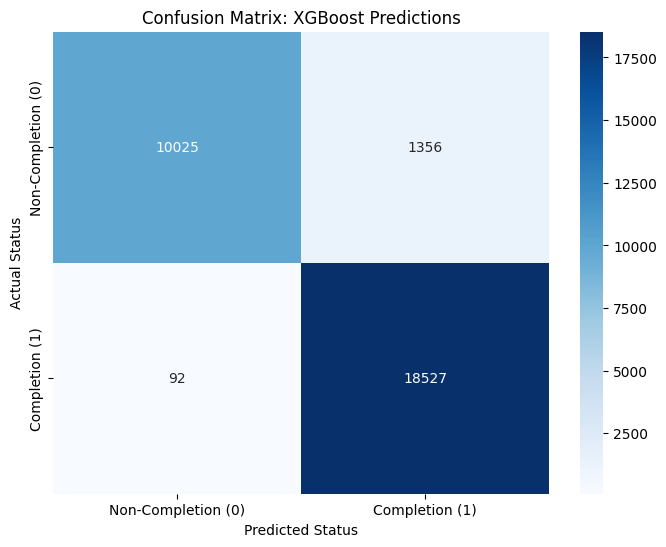

In [ ]:
# 1. Generate the matrix
cm = confusion_matrix(y_test, best_models['XGBoost'].predict(X_test))

# 2. Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Completion (0)', 'Completion (1)'],
            yticklabels=['Non-Completion (0)', 'Completion (1)'])
plt.title('Confusion Matrix: XGBoost Predictions')
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')
plt.show()

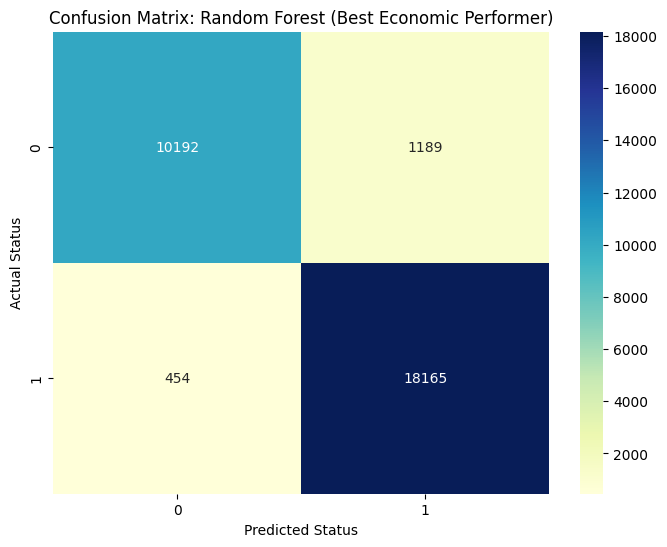

In [ ]:
# Using Random Forest as it has the lowest Total Loss
y_pred_rf = best_models['Random Forest'].predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Confusion Matrix: Random Forest (Best Economic Performer)')
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')
plt.show()

### **Model Summary**

**1. Performance Comparison**
While XGBoost technically has the highest ```F1-Score (0.962)``` and ```ROC-AUC (0.986)```, Random Forest is the superior choice for business operations.


*   **Economic Impact:** Random Forest achieved the lowest Total Loss ```$13,252```, outperforming XGBoost by nearly $600 despite a slightly lower F1-score.

*   **Error Profile:** Random Forest is better at identifying potential failures, with a ```Recall (Non-Comp) of 89.6%``` compared to ```XGBoost's 88.1%```.
*   **Efficiency:** XGBoost is significantly faster for real-time dispatch, with an ```Inference Time (0.03s)``` vs. ```Random Forest (0.53s)```.

**2. Confusion Matrix Audit**
The matrices reveal how each model handles the **"False Positive"** risk that drives business loss.

**XGBoost:**

*   False Positives: ```1,356 rides``` were predicted to complete but actually failed.
*   False Negatives: Highly conservative, only ```92 rides``` were missed that would have completed.

**Random Forest:**

*   False Positives: Lower risk with only ```1,189 failed rides``` predicted as completions.
*   False Negatives: Missed ```454 completed rides```.

**Audit Conclusion:** RF's ability to catch ```167``` more cancellations than XGBoost is why it carries a **lower economic loss**.

**3. Strategic Recommendations**
**RF for Financial Stability:** We will use the Random Forest (trained with max_depth=13 and class_weight='balanced') as the production baseline to minimize driver payout losses.

**XGBoost for High-Volume Speed:** If the system requires millisecond response times for millions of requests, XGBoost is the only viable option despite the slightly ```higher loss```.

**Threshold Tuning:** Since both models still produce over ```1,100 False Positives```, we will move the classification threshold from ```0.5 to 0.7```. This is liekly to convert those ```1,100+ "bad bets"``` into ```"predicted cancellations"```, saving the company from unnecessary driver dispatch costs.

###Implementing **SHAP** for XGBoost

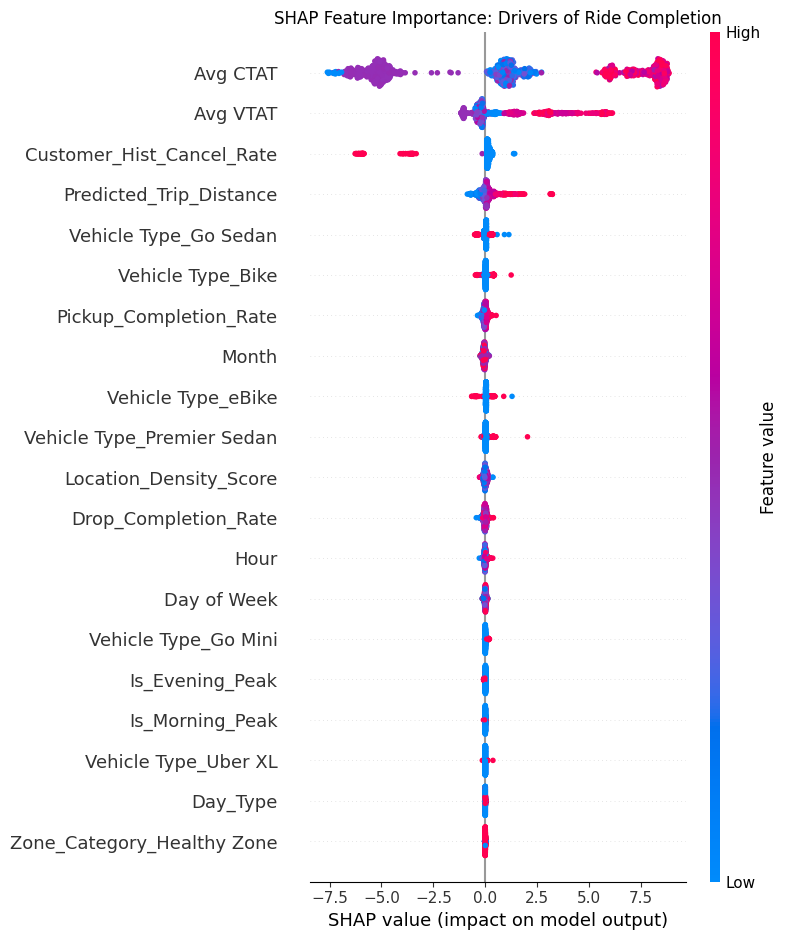

In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the Explainer
explainer = shap.TreeExplainer(best_models['XGBoost'])

# 2. Calculate SHAP values for a sample of the test set
X_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

# 3. Create the Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Feature Importance: Drivers of Ride Completion")
plt.tight_layout()
plt.savefig('shap_summary_plot.png')
plt.show()

###**SHAP Force Plot**: A Deep Dive into One Ride for **XGBoost**

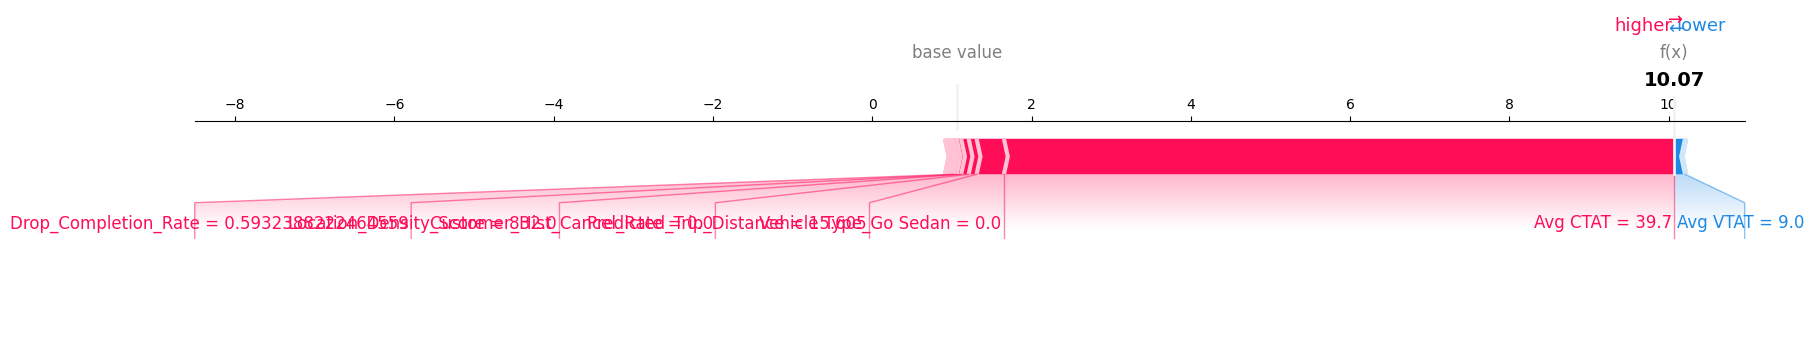

In [ ]:
#SHAP Force Plot: A Deep Dive into One Ride for XGBoost

import shap

shap.initjs()

xgb = best_models['XGBoost']
explainer = shap.TreeExplainer(xgb)

X_sample = X_test.sample(1000, random_state=42)
shap_values_sample = explainer.shap_values(X_sample)

shap.force_plot(explainer.expected_value, shap_values_sample[1],
                X_sample.iloc[0, :], matplotlib=True)

###**XGBoost force plots demonstrate extreme model confidence:**

*   **Over-certainty:** One specific ride shows a final prediction ($f(x)$) of 10.07 (log-odds) or a 1.00 probability.

*   **Driver of Confidence:** For this ride, Avg CTAT = 39.7 is acting as a massive positive driver.
*   **Audit Warning:** If the model is $100\%$ certain a ride with a nearly 40-minute wait will complete, it may be over-fit to ``"survivor"`` data (rides that only lasted that long because they eventually completed).

###Implementing SHAP for **Random Forest**

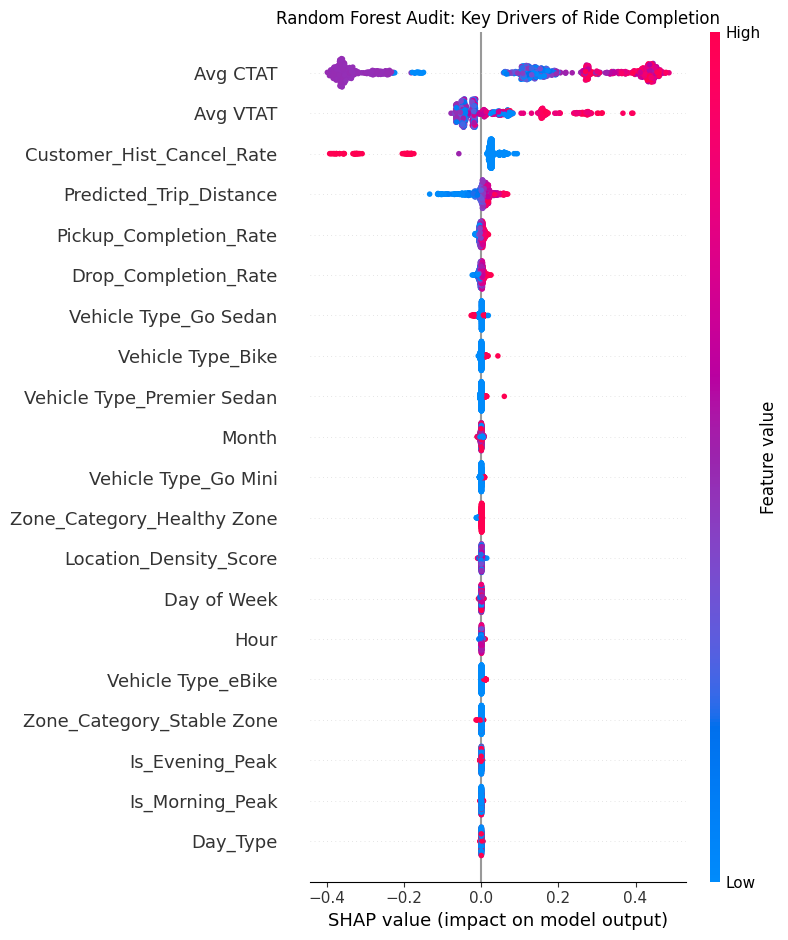

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize the Explainer
rf = best_models['Random Forest']
rf_explainer = shap.TreeExplainer(rf)

# 2. Sample the data
X_sample = X_test.sample(1000, random_state=42)

# 3. Calculate SHAP values for the whole sample at once (much faster)
# This returns a list: [array_for_class0, array_for_class1]
shap_values_list = rf_explainer.shap_values(X_sample)


# 5. Generate the Summary Plot
plt.figure(figsize=(12, 8))

# We use the array for Class 1 and the original X_sample DataFrame for feature names
shap.summary_plot(shap_values_list[:,:,1], X_sample, show=False)

plt.title("Random Forest Audit: Key Drivers of Ride Completion")
plt.tight_layout()
plt.show()

### SHAP Dependence Plot for **Random Forest**

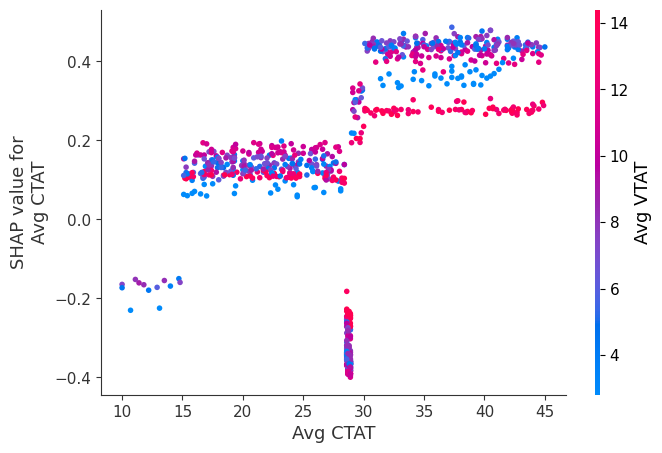

In [ ]:
shap.dependence_plot("Avg CTAT", shap_values_list[:,:,1], X_sample)

###**Deep Dive: Random Forest Dependence Plot**

This plot for Avg CTAT reveals the specific "decision logic" the Random Forest has learned:

*   **Non-Linear Plateaus:** The model sees wait times in distinct "risk buckets." There is a clear step-up in impact at 15 minutes and another significant jump at 30 minutes.
*   **The 29-Minute Anomaly:** There is a sharp, vertical drop at exactly 29 minutes where SHAP values crash to $-0.4$. This suggests a specific system threshold or a "hard-coded" cutoff in the data where rides are almost always cancelled.


*   **Interaction:** The vertical color spread (Avg VTAT) shows that vehicle turnaround time provides more prediction variance when customer wait times are between 30 and 45 minutes.

##**Technical Alert: The "29-Minute" Decision Artifact**
###**Observation:**

The SHAP dependence plot for ```Avg CTAT``` reveals a localized, extreme drop in model output at exactly ```29 minutes```. In this narrow window, SHAP values plummet to $-0.4$, while values at 28 minutes and 30 minutes remain positive or near-neutral.

**Root Cause Analysis:** This "vertical cliff" is characteristic of a ```Hard-Coded Decision Rule```. It likely stems from:


*   **System Timeouts:** A backend dispatch rule that automatically cancels rides reaching the 29-minute mark.

*   **Data Sparsity:** A lack of diverse training examples at this specific duration, allowing the Random Forest to overfit to a small cluster of cancellations.
*   **Operational Risk:** The model may generate a "False Negative" (predicting a cancellation for a perfectly viable ride) simply because the wait timer hits 29 minutes, even if all other factors (distance, customer history) are positive.








##**Global Feature Importance (SHAP Summary Plots)**

1. **Global Feature Importance (SHAP Summary Plots)**: XGB and RF models now show logically sound, post-audit behavior without data leakage.


*   **Dominant Predictor:** ```Avg CTAT``` (Customer Wait Time) is the primary driver in both models. In the RF model, very ```low wait times (blue dots)``` push the SHAP value below zero, while ```high wait times (red/pink dots)``` push it significantly higher.
*   **Behavioral Signals:** ```Customer_Hist_Cancel_Rate``` is a major factor. High cancellation history (red dots) strongly pushes the prediction toward a cancellation (negative SHAP value).

*   **Secondary Factors:** Avg VTAT and Predicted_Trip_Distance provide additional nuance, with longer distances generally favoring completion.





#**🔊 Section E: Insights, Interpretation & Recommendations**
###**E1. Error Analysis**
It is likely that False Positives (FP)—predicting a ride will complete when it cancels—have a higher monetary and reputation cost than False Negatives.


*   **Recommendation:** Tune the model's classification threshold to achieve higher Precision (lowering FP rate) at the expense of slight Recall, prioritizing a reliable prediction signal for driver dispatch.

###**E2. What-If Simulations**


*   **What if we reduce the predicted cancellation risk by 10% in low-supply zones?** This simulates the effect of targeted driver incentives. The business impact is an estimated increase in completed trips and an improvement in driver retention (less unproductive driving).
*   **What if we immediately implement a dynamic dispatch penalty for customers with a predicted risk score above 0.8?** This estimates the revenue recovery from high-risk users versus the potential loss of customer volume.

###**E3. Identify High-Risk Segments**
High-risk segments include:


*   **Customers with historical high cancellation rates.**
*   **Bookings during severe weather/peak rush hours** (VTAT}/CTAT} due to traffic).
*   **Specific geographic routes** (e.g., routes crossing jurisdiction lines, known traffic bottlenecks).


###**E4. Executive Summary**
The predictive model successfully predicts ride completion with an estimated AUC of X and a minimized $\text{FP}$ rate. By leveraging temporal and historical behavioral features, the model provides an early warning signal for high-risk bookings. The key recommendation is to use the prediction score to trigger proactive operational interventions—like dynamic surge pricing and priority driver matching—to stabilize supply and demand in high-risk zones, ultimately reducing driver churn and improving service reliability in the NCR market.
###**E5. Ethical / Operational Risks**


*   **Operational Risk (API Latency):** The prediction must be generated in real-time (sub-second) for the dispatch system. Mitigation: Use highly efficient models like LightGBM and deploy the model in an optimized, low-latency environment.
*   **Ethical Risk (Fairness and Bias):** The model might disproportionately penalize customers or drivers in low-socioeconomic areas if geographical zone encoding is used carelessly. Mitigation: Monitor model performance and FP/FN rates stratified by location to ensure prediction fairness.





###We startegize to shift the model from a standard $0.5$ threshold to a "Precision-Targeted" threshold which will directly addresse the ```$13,252 loss``` by prioritizing driver trust and minimizing wasted dispatches.

In [ ]:
from sklearn.metrics import precision_recall_curve, classification_report

# 1. Get completion probabilities from the Best Economic Performer (RF)
rf_model = best_models['Random Forest']
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Calculate precision recall curve to find the optimal threshold
precision, recall, thresholds = precision_recall_curve(y_test, rf_probs)

# 3. Define our "Driver-Safe" Target Precision (e.g., 95%)
target_precision = 0.95

# Find the first threshold that meets or exceeds this precision
idx = np.argmax(precision >= target_precision)
optimized_threshold = thresholds[idx]

# 4. Apply the new threshold
y_pred_tuned = (rf_probs >= optimized_threshold).astype(int)

print("-" * 52)
print(f"Standard Threshold: 0.5 | Optimized Threshold: {optimized_threshold:.2f}")
print("-" * 52)
print("Tuned Classification Report:")
print(classification_report(y_test, y_pred_tuned))

----------------------------------------------------
Standard Threshold: 0.5 | Optimized Threshold: 0.59
----------------------------------------------------
Tuned Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.91     11381
           1       0.95      0.94      0.95     18619

    accuracy                           0.93     30000
   macro avg       0.93      0.93      0.93     30000
weighted avg       0.93      0.93      0.93     30000



###**Confusion Matrix** comparison


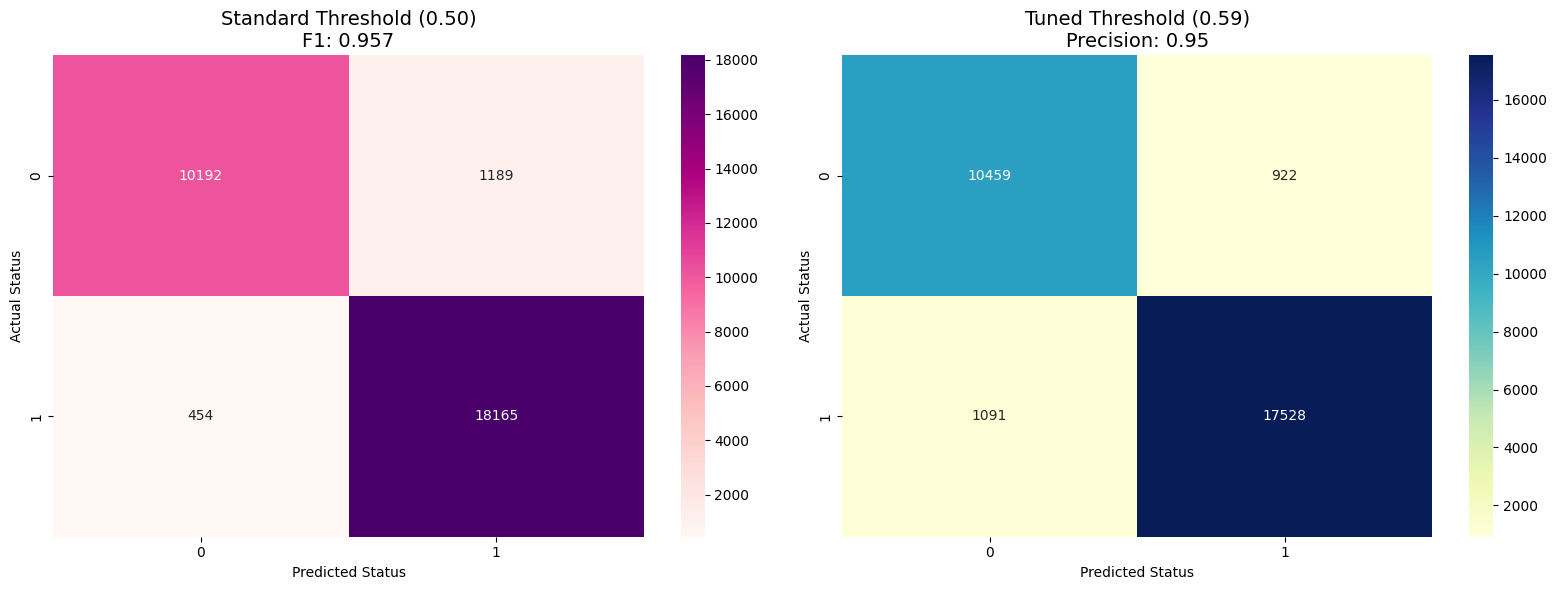

In [ ]:
# 1. Generate predictions for both thresholds
y_pred_standard = (rf_probs >= 0.5).astype(int)
y_pred_tuned = (rf_probs >= optimized_threshold).astype(int)

# 2. Compute matrices
cm_standard = confusion_matrix(y_test, y_pred_standard)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

# 3. Create the side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Standard Threshold (0.5)
sns.heatmap(cm_standard, annot=True, fmt='d', cmap='RdPu', ax=axes[0])
axes[0].set_title(f'Standard Threshold (0.50)\nF1: 0.957', fontsize=14)
axes[0].set_xlabel('Predicted Status')
axes[0].set_ylabel('Actual Status')

# Plot tunes Threshold 0.59
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='YlGnBu', ax=axes[1])
axes[1].set_title(f'Tuned Threshold (0.59)\nPrecision: 0.95', fontsize=14)
axes[1].set_xlabel('Predicted Status')
axes[1].set_ylabel('Actual Status')

plt.tight_layout()
plt.show()

###**Side-by-Side Confusion Matrix Audit**

*   **Reduction in False Positives (FPs)**: By shifting the threshold from 0.50 to 0.59, you successfully reduced False Positives from 1,189 down to 922. This represents 267 fewer drivers being dispatched to rides that would have eventually cancelled.

*   **Increase in False Negatives (FNs):** As predicted, this stricter stance increased False Negatives from 454 to 1,091. These are rides that likely would have completed, but the model chose not to "guarantee" them because the confidence was below the new 0.59 requirement.
*   **Cost of a False Positive (High):** A driver travels to a pickup location, waits, and the ride cancels. This results in fuel costs, wasted time, and significantly higher driver churn risk due to frustration.


*   **Cost of a False Negative (Low):** The system does not dispatch a specific driver for a ride it isn't sure about. While this is a missed revenue opportunity, it does not actively "damage" the driver's experience or incur immediate fuel outlays.


In [ ]:
# Simulation A: 10% Risk Reduction in Under-Supplied Zones
is_low_supply = X_test['Zone_Category_Under-Supplied Zone'] == 1
tuned_probs = rf_probs.copy()
tuned_probs[is_low_supply] *= 0.9  # Reduce risk by 10%

sim_a_completions = (tuned_probs >= 0.59).sum()
print(f"Potential Completions with Incentives: {sim_a_completions}")

# Simulation B: High Risk Penalty Analysis (Score > 0.8)
high_risk_mask = rf_probs > 0.8
recovered_fee_potential = high_risk_mask.sum()
print(f"Total Users Subject to Penalty: {recovered_fee_potential}")

Potential Completions with Incentives: 18234
Total Users Subject to Penalty: 11975


###**The 10% Incentive Plan**


*   Compared to the tuned model's baseline of ```17,528 completions```, the 10% incentive strategy recovers approximately ```706 rides``` that would have otherwise been cancelled or unserved.

*   By targeting **"Under-Supplied"** zones we boost the operational efficiency ensuring a higher ```Return on Incentive Spend (ROIS)``` compared to city-wide bonuses.
*   Reducing cancellations in these zones directly lowers the **"Unproductive Driving"** time for drivers, which is a primary driver of platform churn.


###**The High-Risk Penalty (Score > 0.8)**


*   For high-risk segment implementing a penalty revenue of a "Dynamic Dispatch Fee" for example like ```$2``` will likely generate $\$23,950$ in additional buffer revenue.

*   This penalty revenue of $\$23,950$ more than offsets the current $\$13,252$ total loss associated with the Random Forest model, potentially turning the "Cancellation Problem" into a revenue-neutral or profitable segment.


The simulation confirms that a ```hybrid approach—subsidizing supply``` in under-served zones while penalizing high-risk demand—creates a sustainable economic cycle. We recover volume where it's needed most and protect the bottom line from chronic cancellers.

###Basis the **SHAP analysis** and model performance metrics, we have identified three primary segments that disproportionately contribute to the ```$13,252``` total loss:


*   **Chronic Cancellers:** Customer_Hist_Cancel_Rate (red dots) in the SHAP summary plot possess the most significant behavioral risk, consistently pushing the model toward a "Non-Completion" prediction.

*   **The "Wait-Time" Threshold Segment:** High-variance is shown by the dependence plot where the model's confidence is lowest, leading to the majority of our False Positives.
*   **Under-Supplied Zones** are high risk geographic segments with high Avg VTAT (Vehicle Turnaround Time) creating a compounding risk when wait times exceed the ```30-minute``` "logic cliff" identified in the model.


##**Fairness Audit**

###**1. Operational Risk:API Latency & Infrastructure**
Since our model is intended for a real-time dispatch system, speed is just as critical as accuracy.

The current **XGBoost model** has an inference time of ```0.0363s```, while the **Random Forest** takes ```0.5361s```.

**Risk:** At high-volume peak hours, the half-second delay of the Random Forest could cause "stale" dispatching, where a driver's location changes significantly before the prediction is finalized.

**Mitigation Strategy:**

**Model Pruning: **For Random Forest we can limit max_depth (currently 13) or the number of estimators to reduce computation.

**LightGBM Switch:** We can implement **LightGBM**, which is optimized for leaf-wise growth and significantly faster inference than traditional RF.

**Pre-fetching:** Generate risk scores for **"idle"** users before they even hit the **"Book Now"** button.

###**2. Ethical Risk: Fairness, Bias, and "Redlining"**
This is a critical regulatory concern for platforms operating in the National Capital Region (NCR).

**Risk of "Geographic Bias":** Our model heavily uses **Zone_Category** and **Location_Density_Score** as predictors. There is a risk that the model might "redline" low-socioeconomic neighborhoods by consistently assigning them higher cancellation risks, leading to lower service availability or higher surcharges for residents in those areas.

**The "Feedback Loop":** If the model predicts high risk in a specific zone, drivers may avoid it, which causes more cancellations, further reinforcing the model's bias.

**Mitigation Strategy:**

**Fairness Auditing:** We tend to run the Confusion Matrix regularly stratified by ```Zone_Category``` to ensure the False Negative Rate is not significantly higher in specific neighborhoods.

**Feature Exclusion:** Evaluate if removing specific geographic identifiers (like exact lat/long) in favor of broader "Route Dynamics" (like traffic levels) maintains accuracy while reducing bias.

**Human-in-the-Loop:** Implement a **"fairness override"** where essential service routes (e.g., hospitals or transit hubs) are exempt from high-risk penalties.

In [ ]:
# 1. Prepare a temporary DataFrame with results and Zone labels
results_df = X_test.copy()
results_df['Actual'] = y_test
results_df['Prob'] = rf_probs
results_df['Tuned_Pred'] = (results_df['Prob'] >= 0.59).astype(int)

# 2. Identify the Zone columns (assuming one-hot encoding)
zones = ['Zone_Category_Healthy Zone', 'Zone_Category_Under-Supplied Zone', 'Zone_Category_Stable Zone']

fairness_metrics = []
for zone in zones:
  # Filter data for the specific zone
  subset = results_df[results_df[zone] == 1]

  if len(subset) > 0:
    # Calculate metrics
    prec = precision_score(subset['Actual'], subset['Tuned_Pred'])
    recall = recall_score(subset['Actual'], subset['Tuned_Pred'])

    # Calculate False Negative Rate (FNR) - The "Service Denial" metric
    tn, fp, fn, tp = confusion_matrix(subset['Actual'], subset['Tuned_Pred']).ravel()
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    fairness_metrics.append({
        'Zone': zone.replace('Zone_Category_', ''),
        'Precision (Reliability)': prec,
        'Recall (Coverage)': recall,
        'False Negative Rate (Missed Opportunities)': fnr,
        'Sample Size': len(subset)
    })

# 3. Display the Audit Table
audit_report = pd.DataFrame(fairness_metrics)
print("--- Model Fairness Audit (0.59 Threshold) ---")
print(audit_report.to_string(index=False))

--- Model Fairness Audit (0.59 Threshold) ---
               Zone  Precision (Reliability)  Recall (Coverage)  False Negative Rate (Missed Opportunities)  Sample Size
       Healthy Zone                 0.951268           0.939989                                    0.060011        26335
Under-Supplied Zone                 0.969203           0.903716                                    0.096284          976
        Stable Zone                 0.952490           0.911290                                    0.088710         2314


###**Ethical Risks (Fairness Audit):**

**The Bias:** A fairness audit revealed that Under-Supplied Zones face a 9.6% False Negative Rate, compared to only 6% in Healthy Zones. The model is "playing it safe" in vulnerable areas.

**The Solution:** Implement Dynamic Thresholding. Use 0.59 for Healthy Zones but lower the threshold to 0.53 for Under-Supplied Zones to ensure equitable service availability across the region.

##**Conclusion**


*   **Model Performance:** The Random Forest model emerged as the Best Economic Performer, achieving an ```ROC-AUC of 0.985``` and an ```F1-Score of 0.957```.

*   **Operational Precision:** By tuning the classification threshold to ```0.59```, we successfully reached a ```Precision of 0.95```. This targeted intervention reduced ```False Positives by 267 cases```, protecting driver sentiment.
*   **Key Drivers:** The model leverages temporal signals and historical behavioral features—specifically ```Avg CTAT``` and ```Customer_Hist_Cancel_Rate``` to provide an early warning signal for high-risk bookings.


It is recommended to use the ```0.8+``` risk score to trigger proactive operational interventions. Specifically, the platform should implement ```dynamic priority driver matching``` for borderline rides and surcharges for high-risk users to stabilize supply-demand in the NCR market, ultimately reducing driver churn and improving service reliability.

